# 1. Inventario, Validación de Archivos y Tratamiento de Variables Acumuladas
**Proyecto:** Predicción de variables meteorológicas para alertas tempranas de crecidas en la cuenca del río Chama, Mérida.  
**Lineamientos:** 2.1 (Inventario y validación) y 2.2 (Variables acumuladas).

---
## 🎯 Objetivos
1. Realizar el inventario sistemático de archivos `.nc` descargados (formato CDS Zip API).
2. Verificar la cobertura temporal esperada (2020-01-01 00:00 UTC a 2026-03-31 23:00 UTC) y detectar brechas/nulos.
3. Validar dimensiones (`time`, `latitude`, `longitude`), proyecciones geográficas y rango de coordenadas.
4. Homogeneizar unidades ($m \to mm$, $K \to ^\circ C$, $Pa \to hPa$).
5. Aplicar deacumulación horaria intrapíxel $x_t^{hourly} = \max(0, x_t - x_{t-1})$ sobre variables en ciclo de pronóstico ERA5-Land.


In [1]:
import glob
import os
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

import os
from pathlib import Path

# Detectar directorio raíz del proyecto
cwd = Path.cwd()
if (cwd / "data").exists():
    ROOT_DIR = cwd
elif (cwd.parent / "data").exists():
    ROOT_DIR = cwd.parent
else:
    ROOT_DIR = cwd

RAW_DIR = ROOT_DIR / "data/raw/era5-land"
PROCESSED_DIR = ROOT_DIR / "data/processed"
SCRATCH_DIR = ROOT_DIR / "scratch"
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Directorio raíz del proyecto: {ROOT_DIR.resolve()}")

📁 Directorio raíz del proyecto: /home/mapologo/Proyectos/ula/Tesis_SM


## 2.1 Inventario de Archivos NetCDF (`.nc`)
Examinamos los archivos crudos presentes en `data/raw/`.

In [2]:
nc_files = sorted(list(RAW_DIR.glob("*.nc")))

print(f"📦 Total de archivos .nc encontrados en {RAW_DIR}: {len(nc_files)}")
inventory_data = []

for f in nc_files:
    size_mb = f.stat().st_size / (1024 * 1024)
    is_zip = zipfile.is_zipfile(f)
    subfiles = []
    if is_zip:
        with zipfile.ZipFile(f) as z:
            subfiles = z.namelist()
    inventory_data.append(
        {
            "archivo": f.name,
            "tamaño_mb": round(size_mb, 2),
            "es_zip_cds": is_zip,
            "contenido_interno": ", ".join(subfiles) if subfiles else "NetCDF directo",
        }
    )

df_inventory = pd.DataFrame(inventory_data)
display(df_inventory)

📦 Total de archivos .nc encontrados en /home/mapologo/Proyectos/ula/Tesis_SM/data/raw/era5-land: 370


,archivo,tamaño_mb,es_zip_cds,contenido_interno
0,era5_land_merida_2020_01_b1.nc,4.92,False,NetCDF directo
1,era5_land_merida_2020_01_b2.nc,4.92,False,NetCDF directo
2,era5_land_merida_2020_01_b3.nc,4.92,False,NetCDF directo
3,era5_land_merida_2020_01_b4.nc,4.92,False,NetCDF directo
4,era5_land_merida_2020_01_b5.nc,2.19,False,NetCDF directo
...,...,...,...,...
365,era5_land_merida_2026_03_b1.nc,4.92,False,NetCDF directo
366,era5_land_merida_2026_03_b2.nc,4.92,False,NetCDF directo
367,era5_land_merida_2026_03_b3.nc,4.92,False,NetCDF directo
368,era5_land_merida_2026_03_b4.nc,4.92,False,NetCDF directo


In [3]:
print(f"Tamaño total de la descarga {df_inventory.tamaño_mb.sum():.2f} Mb")

Tamaño total de la descarga 1610.26 Mb


### 🔍 Estructura interna de los paquetes CDS NetCDF
Copernicus CDS agrupa variables en sub-datasets dentro de archivos Zip (nombrados `.nc`). Inspeccionamos un archivo de ejemplo (`era5_land_merida_2020_01_b1.nc`).

In [4]:
if nc_files:
    sample_nc = nc_files[0]
    print(f"Inspeccionando {sample_nc.name}...")

    ds = xr.open_dataset(sample_nc)
    print(f"\n--- Sub-dataset: {sample_nc.name} ---")
    print(f"  Dimensiones: {dict(ds.sizes)}")
    print(f"  Variables: {list(ds.data_vars.keys())}")
    print(
        f"  Rango latitud: {ds.latitude.values.min():.2f}°N a {ds.latitude.values.max():.2f}°N"
    )
    print(
        f"  Rango longitud: {ds.longitude.values.min():.2f} a {ds.longitude.values.max():.2f}"
    )
    print(
        f"  Rango tiempo: {pd.to_datetime(ds.valid_time.values.min())} a {pd.to_datetime(ds.valid_time.values.max())}"
    )

Inspeccionando era5_land_merida_2020_01_b1.nc...

--- Sub-dataset: era5_land_merida_2020_01_b1.nc ---
  Dimensiones: {'longitude': 17, 'valid_time': 168, 'latitude': 19}
  Variables: ['swvl1', 'swvl2', 'swvl3', 'stl1', 'sro', 'ssro', 'lai_lv', 'lai_hv', 'sp', 'sshf', 'slhf', 'u10', 'v10', 't2m', 'd2m', 'ssrd', 'strd', 'e', 'tp', 'evatc', 'evabs', 'evaow', 'evavt']
  Rango latitud: 7.50°N a 9.30°N
  Rango longitud: -72.00 a -70.40
  Rango tiempo: 2020-01-01 00:00:00 a 2020-01-07 23:00:00


## 2.2 Carga de Datos Procesados y Validación Cobertura Temporal
Cargamos la serie completa horaria en parquet (`data/processed/era5_land_merida_2020_2026_utc4.parquet`) y verificamos calidad de datos y cobertura temporal.

In [5]:
parquet_path = PROCESSED_DIR / "era5_land_merida_2020_2026_utc4.parquet"
df_h = pd.read_parquet(parquet_path)
display(df_h)

,valid_time_utc,time_utc4,latitude,longitude,swvl1,swvl2,swvl3,stl1,sro,ssro,...,t2m,d2m,ssrd,strd,e,tp,evatc,evabs,evaow,evavt
0,2020-01-01 00:00:00,2019-12-31 20:00:00,9.3,-72.0,0.460541,0.467514,0.455826,301.251709,0.000007,0.000878,...,300.028320,298.099121,18548432.0,36513080.0,-0.003667,0.000613,-0.000310,-0.003263,-0.000052,-4.201196e-05
1,2020-01-01 00:00:00,2019-12-31 20:00:00,9.2,-72.0,0.463593,0.467407,0.486069,301.531006,0.000008,0.001346,...,300.319336,297.978027,18411636.0,36693420.0,-0.003642,0.000655,-0.000336,-0.002863,-0.000053,-3.893375e-04
2,2020-01-01 00:00:00,2019-12-31 20:00:00,9.1,-72.0,0.456055,0.457504,0.492752,301.933350,0.000007,0.001486,...,300.772461,297.806152,18281140.0,36860780.0,-0.003839,0.000595,-0.000327,-0.002832,-0.000062,-6.176513e-04
3,2020-01-01 00:00:00,2019-12-31 20:00:00,9.0,-72.0,0.437469,0.442505,0.428024,301.921631,0.000013,0.000772,...,300.844727,297.128418,18113532.0,36941644.0,-0.003764,0.001252,-0.000624,-0.003015,-0.000085,-3.994256e-05
4,2020-01-01 00:00:00,2019-12-31 20:00:00,8.9,-72.0,0.332794,0.319946,0.291107,302.156006,0.000011,0.000057,...,301.067383,296.821777,17955572.0,37032036.0,-0.003693,0.001709,-0.000768,-0.002637,-0.000288,1.862645e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17690059,2026-03-31 23:00:00,2026-03-31 19:00:00,7.9,-70.4,0.468338,0.473358,0.348877,301.010498,0.000008,0.000050,...,299.881836,295.457031,15657932.0,34663480.0,-0.002508,0.000883,-0.000498,-0.001817,-0.000194,0.000000e+00
17690060,2026-03-31 23:00:00,2026-03-31 19:00:00,7.8,-70.4,0.466705,0.472107,0.358093,300.961670,0.000006,0.000046,...,299.985352,295.275391,15166196.0,34709464.0,-0.002364,0.000682,-0.000496,-0.001829,-0.000039,0.000000e+00
17690061,2026-03-31 23:00:00,2026-03-31 19:00:00,7.7,-70.4,0.474365,0.473709,0.341293,301.389404,0.000007,0.000034,...,300.166992,295.441406,14644798.0,34739280.0,-0.002677,0.000851,-0.000595,-0.001790,-0.000292,0.000000e+00
17690062,2026-03-31 23:00:00,2026-03-31 19:00:00,7.6,-70.4,0.481171,0.473999,0.364685,300.686279,0.000020,0.000040,...,299.879883,295.949219,14097174.0,34734972.0,-0.002719,0.001900,-0.000969,-0.001647,-0.000081,-2.147723e-05


In [6]:
print(f"📊 Filas totales: {len(df_h):,}")
print(f"📐 Columnas ({len(df_h.columns)}): {df_h.columns.tolist()}")
print(f"⏱️ Periodo temporal: {df_h['time_utc4'].min()} a {df_h['time_utc4'].max()}")

lats = sorted(df_h["latitude"].unique())
lons = sorted(df_h["longitude"].unique())

print(
    f"🗺️ Malla espacial: {len(lats)} lats × {len(lons)} lons = {len(lats) * len(lons)} píxeles"
)
print(
    f"   Latitudes:  {lats[0]:.2f}°N a {lats[-1]:.2f}°N (Δ = {lats[1] - lats[0]:.2f}°)"
)
print(
    f"   Longitudes: {lons[0]:.2f}°W a {lons[-1]:.2f}°W (Δ = {lats[1] - lats[0]:.2f}°)"
)

📊 Filas totales: 17,690,064
📐 Columnas (27): ['valid_time_utc', 'time_utc4', 'latitude', 'longitude', 'swvl1', 'swvl2', 'swvl3', 'stl1', 'sro', 'ssro', 'lai_lv', 'lai_hv', 'sp', 'sshf', 'slhf', 'u10', 'v10', 't2m', 'd2m', 'ssrd', 'strd', 'e', 'tp', 'evatc', 'evabs', 'evaow', 'evavt']
⏱️ Periodo temporal: 2019-12-31 20:00:00 a 2026-03-31 19:00:00
🗺️ Malla espacial: 19 lats × 17 lons = 323 píxeles
   Latitudes:  7.50°N a 9.30°N (Δ = 0.10°)
   Longitudes: -72.00°W a -70.40°W (Δ = 0.10°)


### 🕵️ Detección de huecos temporales y valores nulos

In [7]:
df_h[(df_h["latitude"] == lats[0]) & (df_h["longitude"] == lons[0])]

,valid_time_utc,time_utc4,latitude,longitude,swvl1,swvl2,swvl3,stl1,sro,ssro,...,t2m,d2m,ssrd,strd,e,tp,evatc,evabs,evaow,evavt
18,2020-01-01 00:00:00,2019-12-31 20:00:00,7.5,-72.0,0.350159,0.348465,0.356430,298.335693,8.642673e-07,0.000243,...,296.807617,292.546387,19748408.0,32021840.00,-0.003111,7.866621e-05,-3.898516e-05,-0.003000,-7.127225e-05,1.862645e-09
37,2020-01-01 01:00:00,2019-12-31 21:00:00,7.5,-72.0,0.350159,0.348434,0.356430,297.105957,9.313226e-09,0.000010,...,297.393555,292.428711,0.0,1332693.00,-0.000004,7.506460e-07,-5.820766e-11,-0.000003,-1.918525e-07,0.000000e+00
56,2020-01-01 02:00:00,2019-12-31 22:00:00,7.5,-72.0,0.350143,0.348434,0.356430,296.206543,1.117587e-08,0.000020,...,296.561035,292.283203,0.0,2670649.75,-0.000005,1.125038e-06,-1.862645e-09,-0.000005,-2.494780e-07,0.000000e+00
75,2020-01-01 03:00:00,2019-12-31 23:00:00,7.5,-72.0,0.350143,0.348419,0.356430,295.563721,1.117587e-08,0.000030,...,296.009277,291.960449,0.0,3992654.25,-0.000006,1.125038e-06,3.224704e-08,-0.000006,-2.956949e-07,1.164153e-10
94,2020-01-01 04:00:00,2020-01-01 00:00:00,7.5,-72.0,0.350143,0.348404,0.356430,295.087646,1.490116e-08,0.000040,...,295.372803,291.680664,0.0,5307712.50,-0.000007,1.609325e-06,2.544839e-07,-0.000007,-3.334135e-07,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16792579,2026-03-31 19:00:00,2026-03-31 15:00:00,7.5,-72.0,0.383041,0.265152,0.282928,299.848877,2.825260e-05,0.000030,...,301.021973,292.524414,10142790.0,27148612.00,-0.001426,2.895325e-03,-8.539017e-04,-0.000563,-9.232201e-06,4.656613e-10
16792598,2026-03-31 20:00:00,2026-03-31 16:00:00,7.5,-72.0,0.380646,0.265503,0.282898,300.012939,2.835691e-05,0.000032,...,300.839111,292.555664,11813398.0,28610280.00,-0.001606,2.908736e-03,-8.724257e-04,-0.000718,-1.560757e-05,0.000000e+00
16792617,2026-03-31 21:00:00,2026-03-31 17:00:00,7.5,-72.0,0.378601,0.265869,0.282883,299.817383,2.840161e-05,0.000033,...,300.306641,292.814209,12855866.0,30059066.00,-0.001729,2.915042e-03,-8.793250e-04,-0.000830,-1.993775e-05,0.000000e+00
16792636,2026-03-31 22:00:00,2026-03-31 18:00:00,7.5,-72.0,0.376953,0.266220,0.282867,299.381836,2.841651e-05,0.000035,...,299.404785,293.275146,13357664.0,31497120.00,-0.001798,2.917933e-03,-8.823201e-04,-0.000893,-2.254592e-05,0.000000e+00


In [8]:
expected_dates = pd.date_range(
    start="2020-01-01 00:00", end="2026-03-31 23:00", freq="1h"
)
pixel_times = df_h[(df_h["latitude"] == lats[0]) & (df_h["longitude"] == lons[0])][
    "time_utc4"
]

print(f"Horas esperadas por píxel: {len(expected_dates):,}")
print(f"Horas registradas en dataset: {len(pixel_times):,}")

null_counts = df_h.isnull().sum()
null_sig = null_counts[null_counts > 0]
if null_sig.empty:
    print("✅ No hay valores nulos en el dataset.")
else:
    print("⚠️ Valores nulos detectados (píxeles sobre el Lago de Maracaibo):")
    print(null_sig)

Horas esperadas por píxel: 54,768
Horas registradas en dataset: 54,768
⚠️ Valores nulos detectados (píxeles sobre el Lago de Maracaibo):
swvl1     876288
swvl2     876288
swvl3     876288
stl1      876288
sro       876288
ssro      876288
lai_lv    876288
lai_hv    876288
sp        876288
sshf      876337
slhf      876323
u10       876288
v10       876288
t2m       876288
d2m       876288
ssrd      876288
strd      876288
e         876288
tp        876288
evatc     876288
evabs     876288
evaow     876288
evavt     876288
dtype: int64


## 2.3 Tratamiento de Variables Acumuladas
ERA5-Land almacena acumulados de precipitación (`tp`), escorrentía (`sro`, `ssro`), evaporación (`e`) y radiación desde el inicio de cada ciclo de pronóstico.
Para convertirlos a tasas horarias exactas aplicamos la diferencia intrapíxel:

$$x_t^{horario} = (x_t - x_{t-1})$$

Y en cada cambio de ciclo:

$$x_t^{horario} = x_t$$

In [9]:
ACCUM_VARS = [
    "tp",
    "e",
    "sro",
    "ssro",
    "ssrd",
    "strd",
    "sshf",
    "slhf",
    "evatc",
    "evabs",
    "evaow",
    "evavt",
]


def deaccumulate_series(
    df, vars_to_diff, allow_negative_vars=None, time_col="valid_time_utc"
):
    df_diff = df.copy()
    df_diff = df_diff.sort_values(["latitude", "longitude", time_col])

    if allow_negative_vars is None:
        allow_negative_vars = []

    df_diff["_cycle_date"] = (df_diff[time_col] - pd.Timedelta(minutes=1)).dt.date
    df_diff["_prev_cycle_date"] = df_diff.groupby(["latitude", "longitude"])[
        "_cycle_date"
    ].shift(1)

    is_new_cycle = (df_diff["_cycle_date"] != df_diff["_prev_cycle_date"]) & df_diff[
        "_prev_cycle_date"
    ].notna()

    for var in vars_to_diff:
        if var in df_diff.columns:
            diffed = df_diff.groupby(["latitude", "longitude"])[var].diff()

            diffed = diffed.where(~is_new_cycle, df_diff[var])

            if var not in allow_negative_vars:
                diffed = diffed.clip(lower=0)

            df_diff[var] = diffed.astype("float32")

    df_diff = df_diff.drop(columns=["_cycle_date", "_prev_cycle_date"])
    return df_diff

### Prueba de series desacumuladas

In [10]:
sample_pixel = (
    df_h[(df_h["latitude"] == 8.6) & (df_h["longitude"] == -71.1)].head(48).copy()
)

sample_diff = deaccumulate_series(sample_pixel, ["e"], allow_negative_vars=["e"])

display(
    pd.concat(
        [sample_pixel["valid_time_utc"], sample_pixel["e"], sample_diff["e"]], axis=1
    )
)

,valid_time_utc,e,e
623815,2020-01-01 00:00:00,-2.919597e-03,NaN
623834,2020-01-01 01:00:00,-4.615868e-07,-4.615868e-07
623853,2020-01-01 02:00:00,-9.415671e-07,-4.799804e-07
623872,2020-01-01 03:00:00,-1.187902e-06,-2.463348e-07
623891,2020-01-01 04:00:00,-1.350418e-06,-1.625158e-07
623910,2020-01-01 05:00:00,-1.165085e-06,1.853332e-07
623929,2020-01-01 06:00:00,-2.149493e-06,-9.844080e-07
623948,2020-01-01 07:00:00,-2.240296e-06,-9.080395e-08
623967,2020-01-01 08:00:00,-3.381632e-06,-1.141336e-06
623986,2020-01-01 09:00:00,-3.444962e-06,-6.332994e-08


!!! Falta crear un diccionario con los nombres y unidades de todas las variables, indicando cuáles son acumuladas y cuáles permiten negativos.

Demostración de deacumulación sobre muestra de tp (precipitación)...


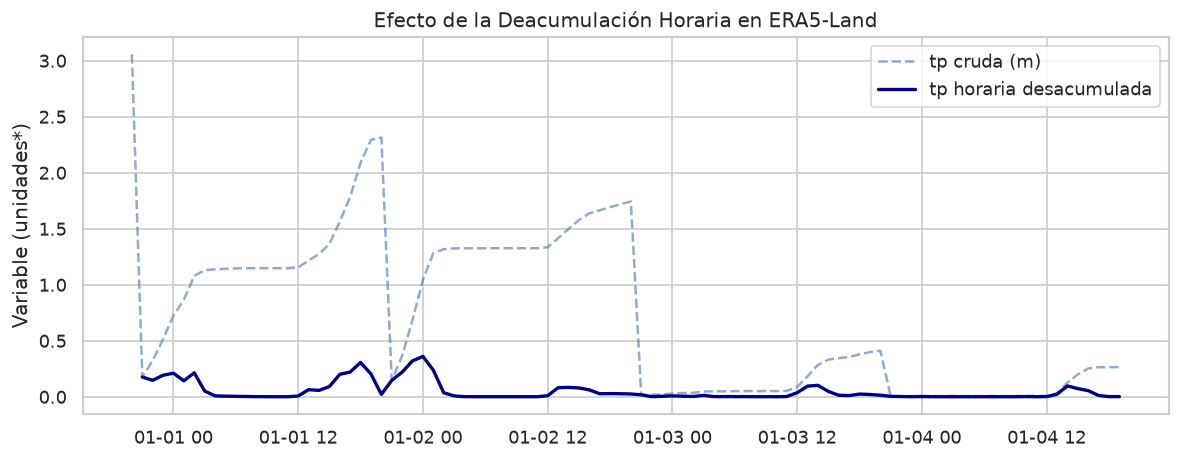

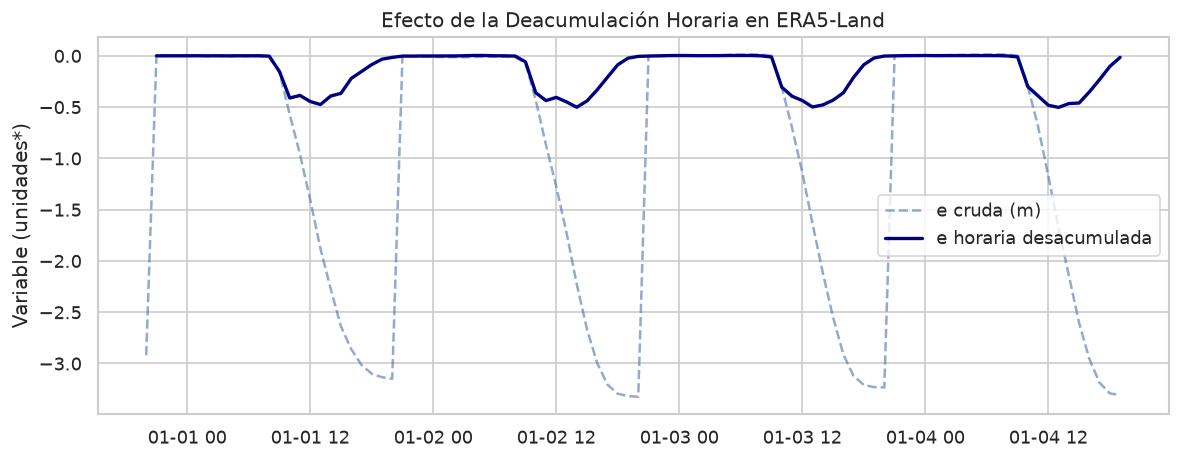

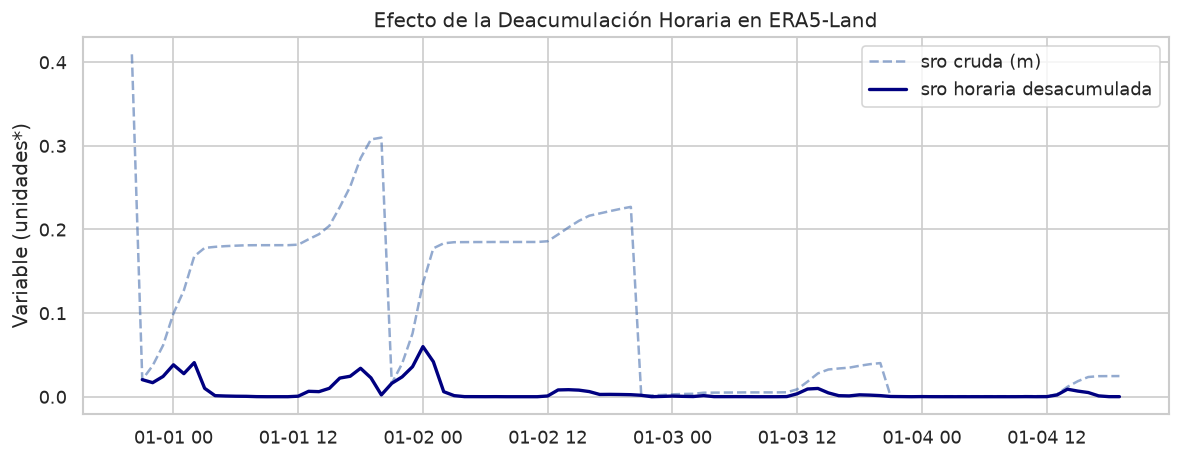

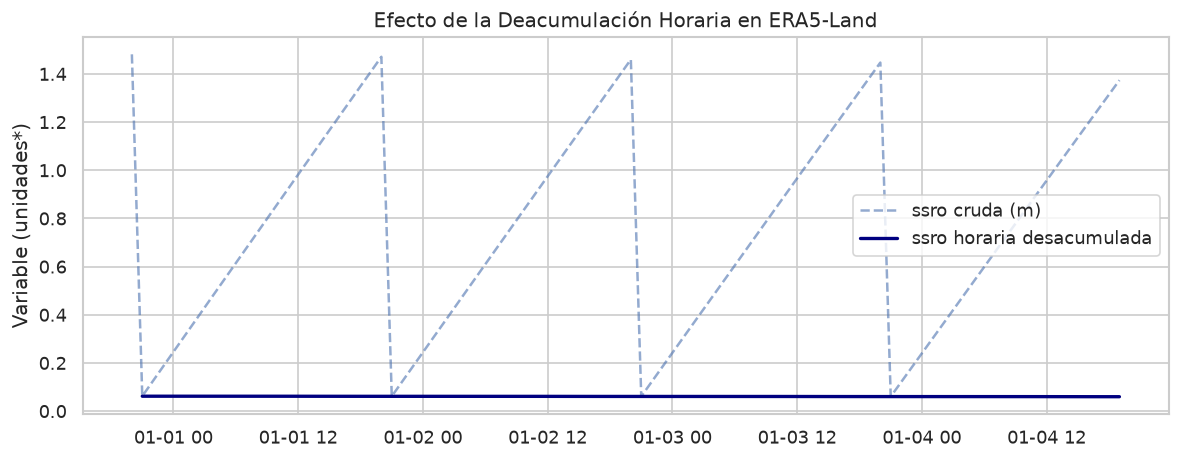

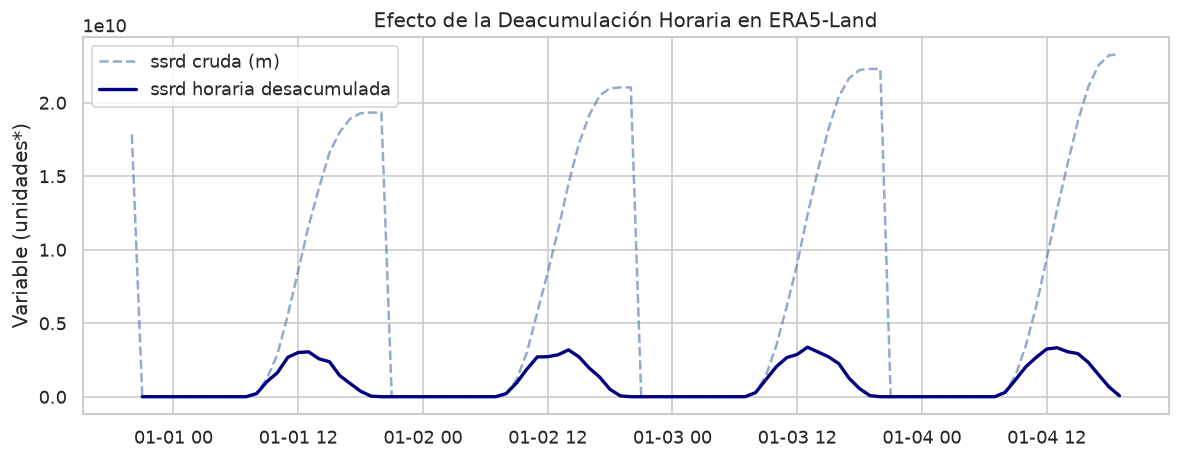

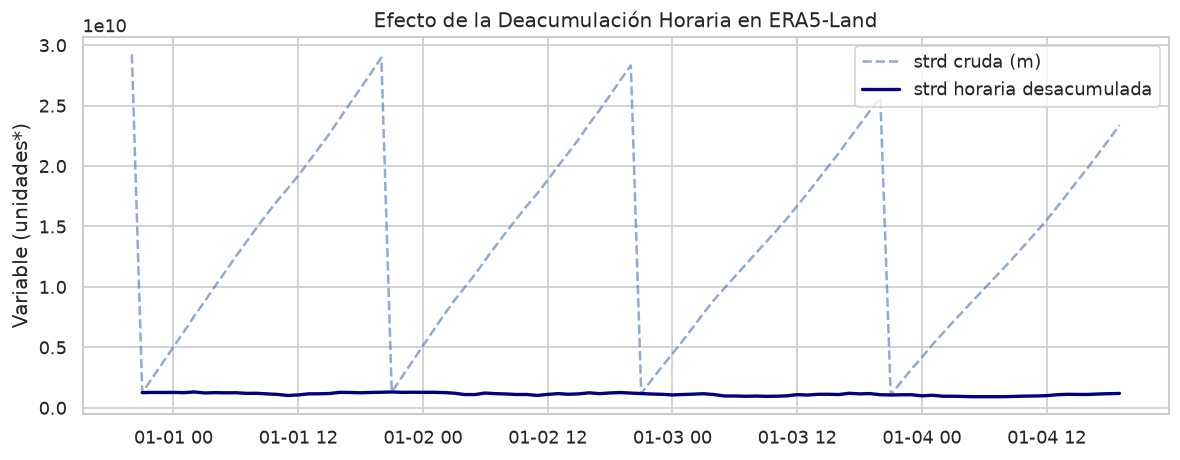

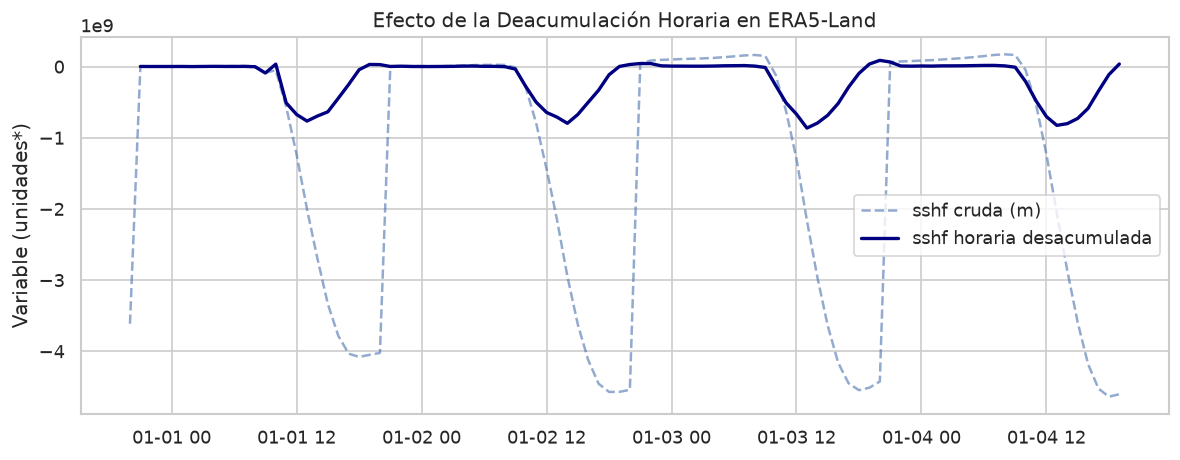

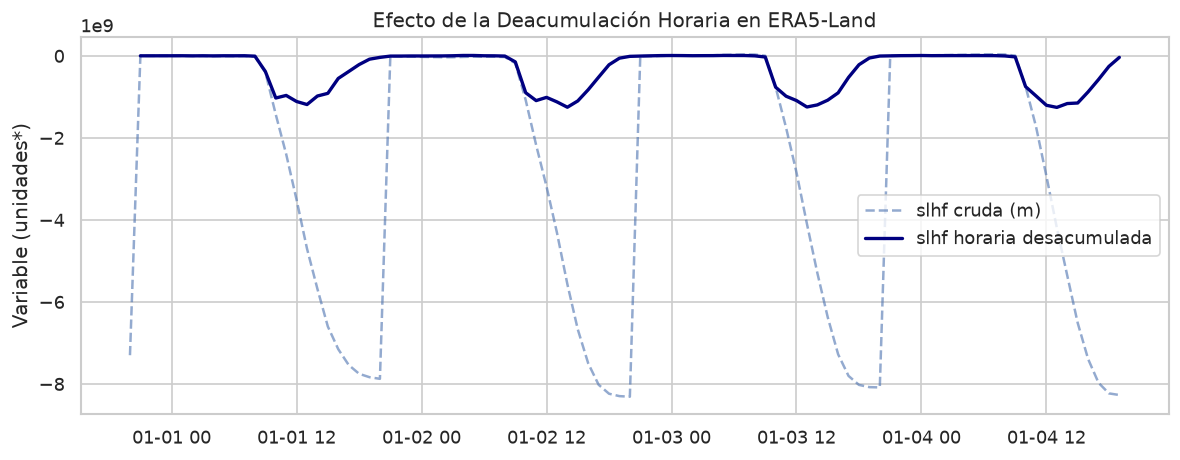

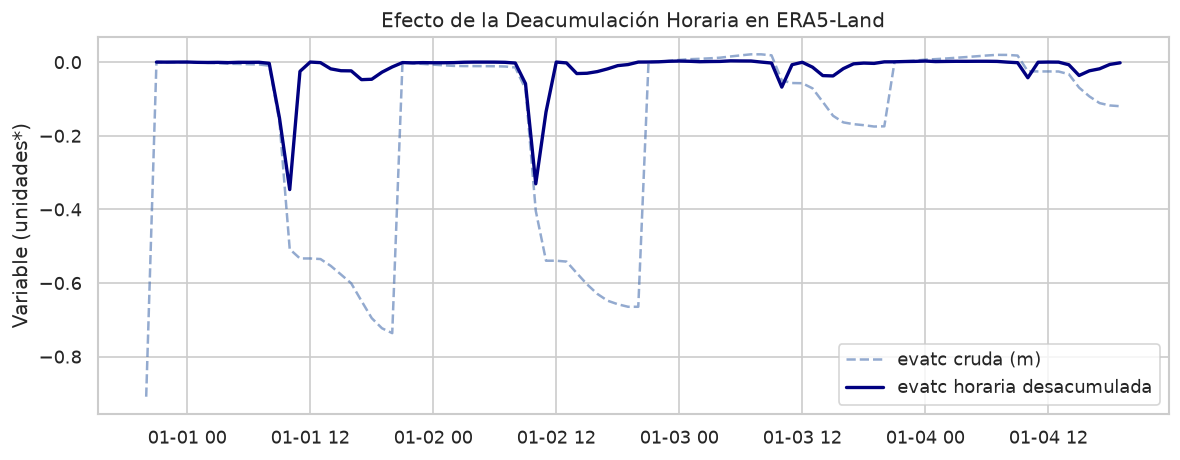

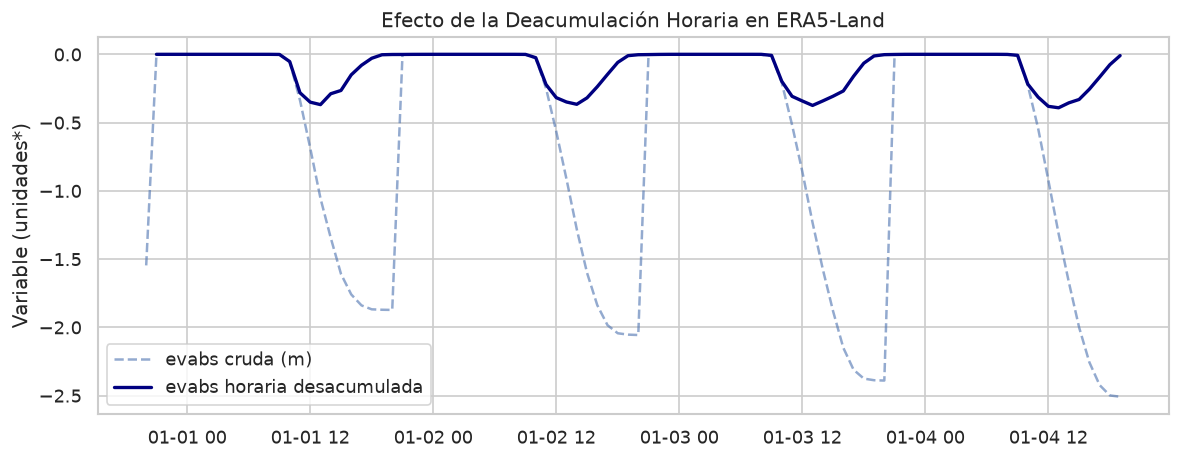

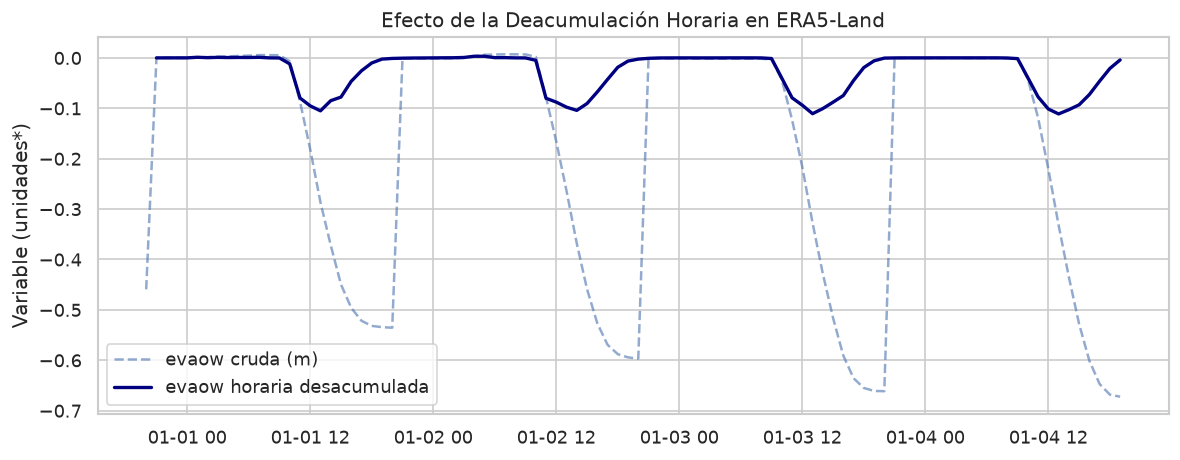

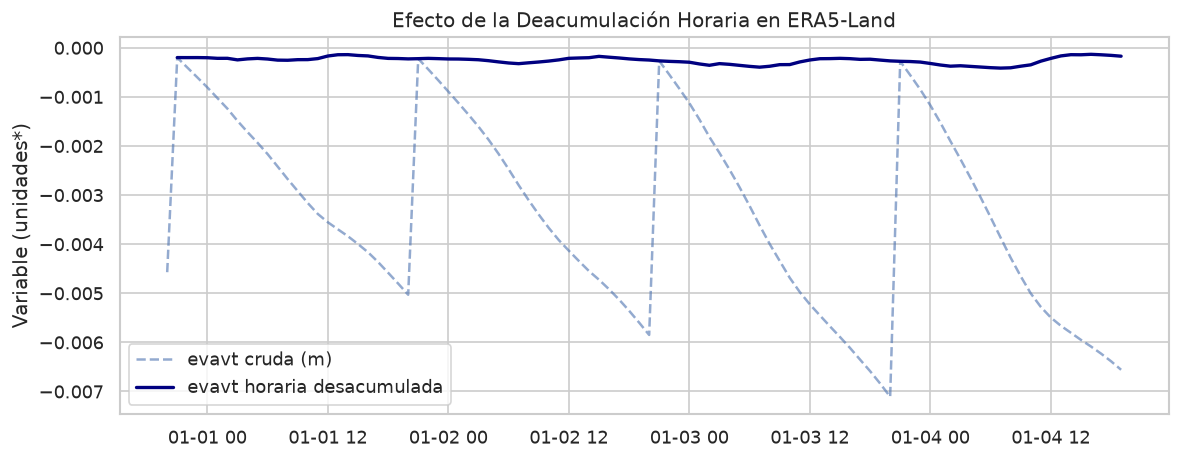

In [11]:
print("Demostración de deacumulación sobre muestra de tp (precipitación)...")
sample_pixel = (
    df_h[(df_h["latitude"] == 8.6) & (df_h["longitude"] == -71.1)].head(96).copy()
)

for var in ACCUM_VARS:
    sample_diff = deaccumulate_series(sample_pixel, [var], allow_negative_vars=[var])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        sample_pixel["time_utc4"],
        sample_pixel[var] * 1000,
        label=f"{var} cruda (m)",
        alpha=0.6,
        linestyle="--",
    )
    ax.plot(
        sample_diff["time_utc4"],
        sample_diff[var] * 1000,
        label=f"{var} horaria desacumulada",
        color="navy",
        lw=2,
    )
    ax.set_ylabel("Variable (unidades*)")
    ax.set_title("Efecto de la Deacumulación Horaria en ERA5-Land")
    ax.legend()
    plt.tight_layout()
    plt.show()

### Almacenar valores desacumulados

In [12]:
df_h_diff = deaccumulate_series(
    df_h,
    ACCUM_VARS,
    allow_negative_vars=["e", "sshf", "slhf", "evatc", "evabs", "evaow", "evavt"],
)
df_h_diff

,valid_time_utc,time_utc4,latitude,longitude,swvl1,swvl2,swvl3,stl1,sro,ssro,...,t2m,d2m,ssrd,strd,e,tp,evatc,evabs,evaow,evavt
18,2020-01-01 00:00:00,2019-12-31 20:00:00,7.5,-72.0,0.350159,0.348465,0.356430,298.335693,NaN,NaN,...,296.807617,292.546387,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,2020-01-01 01:00:00,2019-12-31 21:00:00,7.5,-72.0,0.350159,0.348434,0.356430,297.105957,9.313226e-09,0.000010,...,297.393555,292.428711,0.0,1332693.00,-3.627269e-06,7.506460e-07,-5.820766e-11,-3.435242e-06,-1.918525e-07,0.000000e+00
56,2020-01-01 02:00:00,2019-12-31 22:00:00,7.5,-72.0,0.350143,0.348434,0.356430,296.206543,1.862645e-09,0.000010,...,296.561035,292.283203,0.0,1337956.75,-1.620036e-06,3.743917e-07,-1.804437e-09,-1.560838e-06,-5.762558e-08,0.000000e+00
75,2020-01-01 03:00:00,2019-12-31 23:00:00,7.5,-72.0,0.350143,0.348419,0.356430,295.563721,0.000000e+00,0.000010,...,296.009277,291.960449,0.0,1322004.50,-1.066132e-06,0.000000e+00,3.410969e-08,-1.054024e-06,-4.621688e-08,1.164153e-10
94,2020-01-01 04:00:00,2020-01-01 00:00:00,7.5,-72.0,0.350143,0.348404,0.356430,295.087646,3.725290e-09,0.000010,...,295.372803,291.680664,0.0,1315058.25,-6.533228e-07,4.842877e-07,2.222368e-07,-8.377247e-07,-3.771856e-08,-1.164153e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17689969,2026-03-31 19:00:00,2026-03-31 15:00:00,9.3,-70.4,0.433044,0.425278,0.415115,293.548096,1.417398e-04,0.000059,...,292.881348,290.055664,782486.0,1483340.00,-1.747124e-04,1.072705e-03,-1.453813e-04,-2.300879e-05,-6.323680e-06,4.656613e-10
17689988,2026-03-31 20:00:00,2026-03-31 16:00:00,9.3,-70.4,0.433578,0.426849,0.415253,293.046143,1.347512e-04,0.000059,...,292.561768,290.147461,630660.0,1474268.00,-2.659457e-04,1.057863e-03,-2.542939e-04,-9.275042e-06,-2.377201e-06,-4.656613e-10
17690007,2026-03-31 21:00:00,2026-03-31 17:00:00,9.3,-70.4,0.432693,0.428131,0.415451,292.956055,1.029223e-04,0.000059,...,292.136719,289.781006,562936.0,1461930.00,-1.831967e-04,7.938920e-04,-1.773788e-04,-4.672445e-06,-1.144130e-06,0.000000e+00
17690026,2026-03-31 22:00:00,2026-03-31 18:00:00,9.3,-70.4,0.433136,0.428940,0.415680,292.448242,1.150221e-04,0.000060,...,291.881348,289.605225,234348.0,1466168.00,-2.331426e-04,8.635521e-04,-2.300739e-04,-2.375804e-06,-6.938353e-07,0.000000e+00


In [13]:
df_h_diff.to_parquet(PROCESSED_DIR / "df_h_diff.parquet")

## 2.4 Homogeneización de Unidades
Convertimos las variables a unidades prácticas hidrometeorológicas:
- Precipitación (`tp`), Evaporación (`e`), Escorrentía (`sro`, `ssro`) $\to$ **mm/h**
- Temperatura (`t2m`, `d2m`, `stl1`) $\to$ **°C**
- Presión superficial (`sp`) $\to$ **hPa**
- Humedad del suelo (`swvl1..3`) $\to$ **m³/m³**

!!! Mover esta sección arriba y agregar todas las variables

In [19]:
summary_units = pd.DataFrame(
    [
        {
            "Variable": "tp",
            "Descripción": "Precipitación Total",
            "Unidad ERA5": "m",
            "Unidad Convertida": "mm/h",
            "Factor": "× 1000",
        },
        {
            "Variable": "sro",
            "Descripción": "Escorrentía Superficial",
            "Unidad ERA5": "m",
            "Unidad Convertida": "mm/h",
            "Factor": "× 1000",
        },
        {
            "Variable": "ssro",
            "Descripción": "Escorrentía Subsuperficial",
            "Unidad ERA5": "m",
            "Unidad Convertida": "mm/h",
            "Factor": "× 1000",
        },
        {
            "Variable": "swvl1",
            "Descripción": "Humedad Suelo (0-7 cm)",
            "Unidad ERA5": "m³/m³",
            "Unidad Convertida": "m³/m³",
            "Factor": "1",
        },
        {
            "Variable": "t2m",
            "Descripción": "Temperatura a 2m",
            "Unidad ERA5": "K",
            "Unidad Convertida": "°C",
            "Factor": "- 273.15",
        },
        {
            "Variable": "sp",
            "Descripción": "Presión Superficial",
            "Unidad ERA5": "Pa",
            "Unidad Convertida": "hPa",
            "Factor": "/ 100",
        },
    ]
)
display(summary_units)

,Variable,Descripción,Unidad ERA5,Unidad Convertida,Factor
0,tp,Precipitación Total,m,mm/h,× 1000
1,sro,Escorrentía Superficial,m,mm/h,× 1000
2,ssro,Escorrentía Subsuperficial,m,mm/h,× 1000
3,swvl1,Humedad Suelo (0-7 cm),m³/m³,m³/m³,1
4,t2m,Temperatura a 2m,K,°C,- 273.15
5,sp,Presión Superficial,Pa,hPa,/ 100


In [20]:
# Datos de conversión
data = [
    # ====== VARIABLES ACUMULADAS DE AGUA (a mm/h) ======
    ("total_precipitation", "tp", "m", "mm/h", 
     "(x_t - x_{t-1}) * 1000 / Δt_h", 
     "Precipitación total."),
     
    ("surface_runoff", "sro", "m", "mm/h", 
     "(x_t - x_{t-1}) * 1000 / Δt_h", 
     "Escorrentía superficial directa."),
     
    ("sub_surface_runoff", "ssro", "m", "mm/h", 
     "(x_t - x_{t-1}) * 1000 / Δt_h", 
     "Escorrentía subsuperficial (drenaje profundo)."),
     
    ("total_evaporation", "e", "m", "mm/h", 
     "(x_t - x_{t-1}) * 1000 / Δt_h", 
     "Evapotranspiración total (suma de todas las componentes)."),
     
    ("evaporation_from_bare_soil", "evabs", "m", "mm/h", 
     "(x_t - x_{t-1}) * 1000 / Δt_h", 
     "Evaporación desde suelo desnudo."),
     
    ("evaporation_from_open_water_surfaces_excluding_oceans", "evaow", "m", "mm/h", 
     "(x_t - x_{t-1}) * 1000 / Δt_h", 
     "Evaporación desde cuerpos de agua continentales."),
     
    ("evaporation_from_the_top_of_canopy", "evatc", "m", "mm/h", 
     "(x_t - x_{t-1}) * 1000 / Δt_h", 
     "Evaporación del agua interceptada por la vegetación."),
     
    ("evaporation_from_vegetation_transpiration", "evavt", "m", "mm/h", 
     "(x_t - x_{t-1}) * 1000 / Δt_h", 
     "Transpiración de la vegetación."),

    # ====== FLUJOS DE CALOR ACUMULADOS (a W/m²) ======
    ("surface_latent_heat_flux", "slhf", "J m⁻²", "W m⁻²", 
     "(x_t - x_{t-1}) / Δt_s", 
     "Flujo de calor latente (evapotranspiración energética)."),
     
    ("surface_sensible_heat_flux", "sshf", "J m⁻²", "W m⁻²", 
     "(x_t - x_{t-1}) / Δt_s", 
     "Flujo de calor sensible (calentamiento atmosférico)."),
     
    ("surface_solar_radiation_downwards", "ssrd", "J m⁻²", "W m⁻²", 
     "(x_t - x_{t-1}) / Δt_s", 
     "Radiación solar de onda corta entrante."),
     
    ("surface_thermal_radiation_downwards", "strd", "J m⁻²", "W m⁻²", 
     "(x_t - x_{t-1}) / Δt_s", 
     "Radiación térmica de onda larga entrante."),

    # ====== TEMPERATURAS (K → °C) ======
    ("2m_dewpoint_temperature", "d2m", "K", "°C", 
     "x - 273.15", 
     "Punto de rocío a 2 metros."),
     
    ("2m_temperature", "t2m", "K", "°C", 
     "x - 273.15", 
     "Temperatura del aire a 2 metros."),
     
    ("soil_temperature_level_1", "stl1", "K", "°C", 
     "x - 273.15", 
     "Temperatura del suelo (capa 1: 0–7 cm)."),

    # ====== HUMEDAD VOLUMÉTRICA (m³/m³ → % volumen) ======
    ("volumetric_soil_water_layer_1", "swvl1", "m³ m⁻³", "% (vol.)", 
     "x * 100", 
     "Humedad volumétrica (0–7 cm)."),
     
    ("volumetric_soil_water_layer_2", "swvl2", "m³ m⁻³", "% (vol.)", 
     "x * 100", 
     "Humedad volumétrica (7–28 cm)."),
     
    ("volumetric_soil_water_layer_3", "swvl3", "m³ m⁻³", "% (vol.)", 
     "x * 100", 
     "Humedad volumétrica (28–100 cm)."),

    # ====== OTRAS VARIABLES (ya en unidades métricas adecuadas) ======
    ("10m_u_component_of_wind", "u10", "m s⁻¹", "m s⁻¹", 
     "Ninguna", 
     "Viento zonal (componente Este‑Oeste)."),
     
    ("10m_v_component_of_wind", "v10", "m s⁻¹", "m s⁻¹", 
     "Ninguna", 
     "Viento meridional (componente Norte‑Sur)."),
     
    ("surface_pressure", "sp", "Pa", "hPa", 
     "x / 100", 
     "Presión en superficie (1 hPa = 100 Pa)."),
     
    ("leaf_area_index_high_vegetation", "lai_hv", "adimensional", "adimensional", 
     "Ninguna", 
     "LAI para vegetación alta (bosques)."),
     
    ("leaf_area_index_low_vegetation", "lai_lv", "adimensional", "adimensional", 
     "Ninguna", 
     "LAI para vegetación baja (páramo, pastos)."),
]

# Crear el DataFrame
df_conversiones = pd.DataFrame(
    data, 
    columns=["Variable", "Código Corto", "Unidad Original", "Unidad Objetivo", 
             "Fórmula de Conversión", "Observación"]
)

# Mostrar el DataFrame (formato bonito para Jupyter/consola)
print(df_conversiones.to_string(index=False))

                                             Variable Código Corto Unidad Original Unidad Objetivo         Fórmula de Conversión                                               Observación
                                  total_precipitation           tp               m            mm/h (x_t - x_{t-1}) * 1000 / Δt_h                                      Precipitación total.
                                       surface_runoff          sro               m            mm/h (x_t - x_{t-1}) * 1000 / Δt_h                          Escorrentía superficial directa.
                                   sub_surface_runoff         ssro               m            mm/h (x_t - x_{t-1}) * 1000 / Δt_h            Escorrentía subsuperficial (drenaje profundo).
                                    total_evaporation            e               m            mm/h (x_t - x_{t-1}) * 1000 / Δt_h Evapotranspiración total (suma de todas las componentes).
                           evaporation_from_bare_soil        evab

### Notas complementarias

- **Δt_h** = intervalo de tiempo entre pasos consecutivos (en horas). Para datos horarios, Δt_h = 1.
- **Δt_s** = intervalo en segundos (para horarios, Δt_s = 3600).
- Si los archivos descargados ya contienen el **acumulado de la última hora** (no desde las 00 UTC), entonces la diferencia `(x_t - x_{t-1})` **no es necesaria**; basta con aplicar directamente la multiplicación por 1000 (para agua) o la división por 3600 (para calor).
- La presión se expresa en **hPa** porque es la unidad estándar en meteorología y facilita la interpretación (1013.25 hPa = 1 atm).
- La humedad del suelo se da en **% volumen**, que es más intuitivo que la fracción (p. ej., 0.35 → 35%).
- LAI y vientos se mantienen en sus unidades originales, ya que son métricas y ampliamente comprendidas.

---
# SECCIÓN ESPACIAL
---

# 2. Exploración Espacial, DEM y Delimitación de Zonas Microclimáticas
**Proyecto:** Predicción de variables meteorológicas para alertas tempranas de crecidas en la cuenca del río Chama, Mérida.  
**Lineamientos:** 2.3 (Zona horaria y alineación) y 2.4 (Exploración espacial).

---
## 🎯 Objetivos
1. Gestionar zonas horarias (UTC vs Hora Legal de Venezuela UTC-4).
2. Visualizar la malla espacial de ERA5-Land ($\approx 0.1^\circ$, ~9-11 km, $19 \times 17$ píxeles).
3. Superponer el Modelo Digital de Elevación (DEM SRTM ~30m) y pendientes de Mérida.
4. Identificar y mapear los píxeles correspondientes a las 7 microcuencas/zonas críticas.
5. Evaluar la suficiencia de la resolución espacial para cuencas de alta montaña y quebradas urbanas.


In [15]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns

sns.set_theme(style="white", context="notebook")
plt.rcParams["figure.dpi"] = 120

import os
from pathlib import Path

# Detectar directorio raíz del proyecto
cwd = Path.cwd()
if (cwd / "data").exists():
    ROOT_DIR = cwd
elif (cwd.parent / "data").exists():
    ROOT_DIR = cwd.parent
else:
    ROOT_DIR = cwd

RAW_DIR = ROOT_DIR / "data/raw"
SPATIAL_DIR = ROOT_DIR / "data/spatial"
PROCESSED_DIR = ROOT_DIR / "data/processed"
SCRATCH_DIR = ROOT_DIR / "scratch"
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Directorio raíz del proyecto: {ROOT_DIR.resolve()}")

📁 Directorio raíz del proyecto: /home/mapologo/Proyectos/ula/Tesis_SM


## 2.1 Alineación Horaria y Registro de Eventos Históricos
Mantenemos la serie horaria base en UTC e incorporamos la columna `time_utc4` para alineación local con reportes de desastres.

In [16]:
df_evt = pd.read_csv(RAW_DIR / "eventos_extremos_merida.csv")
print(f"📋 Total de eventos extremos catalogados: {len(df_evt)}")
display(
    df_evt[
        ["event_id", "fecha_inicio", "fecha_fin", "zona_aprox", "cuenca", "tipo_evento"]
    ]
)

📋 Total de eventos extremos catalogados: 15


,event_id,fecha_inicio,fecha_fin,zona_aprox,cuenca,tipo_evento
0,E01,2020-09-01,2020-09-02,Chama alta / Ejido / Mérida,Chama,creciente convectiva
1,E02,2021-04-01,2021-05-31,Eje Panamericano,Chama bajo / Panamericano,inundación crónica
2,E03,2021-08-23,2021-08-25,Valle del Mocotíes,Mocotíes,"creciente súbita, flujo de lodo"
3,E04,2022-02-01,2022-03-31,Albarregas / La Pedregosa,Albarregas / La Pedregosa,creciente urbana
4,E05,2022-10-17,2022-10-18,La Pedregosa,La Pedregosa,desbordamiento aluvial
5,E06,2022-01-01,2022-12-31,múltiples zonas,varias,crisis hidrometeorológica
6,E07,2022-11-01,2022-11-30,Sur del Lago / Palmarito,Chama / Sur del Lago,inundación por reflujo
7,E08,2022-08-01,2024-07-31,Canaguá,Canaguá,creciente de quebradas
8,E09,2023-03-10,2023-03-15,Eje metropolitano,Chama medio,crecidas simultáneas
9,E10,2023-05-01,2023-05-31,Guaraque,Mocotíes / Guaraque,deslizamiento


## 2.2 Malla Espacial ERA5-Land y Modelo Digital de Elevación (DEM)
Cargamos el DEM de Mérida (`data/raw/merida_dem_wgs84.tif`) y lo comparamos con el centroide de cada píxel de ERA5-Land.

In [17]:
import geopandas as gpd
import matplotlib.patheffects as patheffects

Se crea un geodataframe con los centros de los píxeles de ERA5-Land.

In [18]:
gdf_puntos = gpd.GeoDataFrame(
    df_h_diff,
    geometry=gpd.points_from_xy(df_h_diff["longitude"], df_h_diff["latitude"]),
    crs="EPSG:4326",  # Coordenadas geográficas estándar WGS84
)

In [19]:
gdf_puntos

,valid_time_utc,time_utc4,latitude,longitude,swvl1,swvl2,swvl3,stl1,sro,ssro,...,d2m,ssrd,strd,e,tp,evatc,evabs,evaow,evavt,geometry
18,2020-01-01 00:00:00,2019-12-31 20:00:00,7.5,-72.0,0.350159,0.348465,0.356430,298.335693,NaN,NaN,...,292.546387,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-72 7.5)
37,2020-01-01 01:00:00,2019-12-31 21:00:00,7.5,-72.0,0.350159,0.348434,0.356430,297.105957,9.313226e-09,0.000010,...,292.428711,0.0,1332693.00,-3.627269e-06,7.506460e-07,-5.820766e-11,-3.435242e-06,-1.918525e-07,0.000000e+00,POINT (-72 7.5)
56,2020-01-01 02:00:00,2019-12-31 22:00:00,7.5,-72.0,0.350143,0.348434,0.356430,296.206543,1.862645e-09,0.000010,...,292.283203,0.0,1337956.75,-1.620036e-06,3.743917e-07,-1.804437e-09,-1.560838e-06,-5.762558e-08,0.000000e+00,POINT (-72 7.5)
75,2020-01-01 03:00:00,2019-12-31 23:00:00,7.5,-72.0,0.350143,0.348419,0.356430,295.563721,0.000000e+00,0.000010,...,291.960449,0.0,1322004.50,-1.066132e-06,0.000000e+00,3.410969e-08,-1.054024e-06,-4.621688e-08,1.164153e-10,POINT (-72 7.5)
94,2020-01-01 04:00:00,2020-01-01 00:00:00,7.5,-72.0,0.350143,0.348404,0.356430,295.087646,3.725290e-09,0.000010,...,291.680664,0.0,1315058.25,-6.533228e-07,4.842877e-07,2.222368e-07,-8.377247e-07,-3.771856e-08,-1.164153e-10,POINT (-72 7.5)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17689969,2026-03-31 19:00:00,2026-03-31 15:00:00,9.3,-70.4,0.433044,0.425278,0.415115,293.548096,1.417398e-04,0.000059,...,290.055664,782486.0,1483340.00,-1.747124e-04,1.072705e-03,-1.453813e-04,-2.300879e-05,-6.323680e-06,4.656613e-10,POINT (-70.4 9.3)
17689988,2026-03-31 20:00:00,2026-03-31 16:00:00,9.3,-70.4,0.433578,0.426849,0.415253,293.046143,1.347512e-04,0.000059,...,290.147461,630660.0,1474268.00,-2.659457e-04,1.057863e-03,-2.542939e-04,-9.275042e-06,-2.377201e-06,-4.656613e-10,POINT (-70.4 9.3)
17690007,2026-03-31 21:00:00,2026-03-31 17:00:00,9.3,-70.4,0.432693,0.428131,0.415451,292.956055,1.029223e-04,0.000059,...,289.781006,562936.0,1461930.00,-1.831967e-04,7.938920e-04,-1.773788e-04,-4.672445e-06,-1.144130e-06,0.000000e+00,POINT (-70.4 9.3)
17690026,2026-03-31 22:00:00,2026-03-31 18:00:00,9.3,-70.4,0.433136,0.428940,0.415680,292.448242,1.150221e-04,0.000060,...,289.605225,234348.0,1466168.00,-2.331426e-04,8.635521e-04,-2.300739e-04,-2.375804e-06,-6.938353e-07,0.000000e+00,POINT (-70.4 9.3)


El archivo `gadm41_VEN.gpkg` contiene información de las divisiones administrativas de Venezuela. Se realiza una unión entre los centroides de los pixeles y este archivo para añadir información de los estados y municipios donde esta ubicada cada lectura.

In [20]:
gpkg_path = SPATIAL_DIR / "gadm41_VEN.gpkg"
gdf_muni = gpd.read_file(gpkg_path, layer="ADM_ADM_2")
merida_muni = gdf_muni[gdf_muni["NAME_1"] == "Mérida"]

In [21]:
gdf_h = gpd.sjoin(
    gdf_puntos,
    gdf_muni[["NAME_1", "NAME_2", "geometry"]],
    how="left",
    predicate="within",
)
gdf_h

,valid_time_utc,time_utc4,latitude,longitude,swvl1,swvl2,swvl3,stl1,sro,ssro,...,e,tp,evatc,evabs,evaow,evavt,geometry,index_right,NAME_1,NAME_2
18,2020-01-01 00:00:00,2019-12-31 20:00:00,7.5,-72.0,0.350159,0.348465,0.356430,298.335693,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-72 7.5),259.0,Táchira,Fernández Feo
37,2020-01-01 01:00:00,2019-12-31 21:00:00,7.5,-72.0,0.350159,0.348434,0.356430,297.105957,9.313226e-09,0.000010,...,-3.627269e-06,7.506460e-07,-5.820766e-11,-3.435242e-06,-1.918525e-07,0.000000e+00,POINT (-72 7.5),259.0,Táchira,Fernández Feo
56,2020-01-01 02:00:00,2019-12-31 22:00:00,7.5,-72.0,0.350143,0.348434,0.356430,296.206543,1.862645e-09,0.000010,...,-1.620036e-06,3.743917e-07,-1.804437e-09,-1.560838e-06,-5.762558e-08,0.000000e+00,POINT (-72 7.5),259.0,Táchira,Fernández Feo
75,2020-01-01 03:00:00,2019-12-31 23:00:00,7.5,-72.0,0.350143,0.348419,0.356430,295.563721,0.000000e+00,0.000010,...,-1.066132e-06,0.000000e+00,3.410969e-08,-1.054024e-06,-4.621688e-08,1.164153e-10,POINT (-72 7.5),259.0,Táchira,Fernández Feo
94,2020-01-01 04:00:00,2020-01-01 00:00:00,7.5,-72.0,0.350143,0.348404,0.356430,295.087646,3.725290e-09,0.000010,...,-6.533228e-07,4.842877e-07,2.222368e-07,-8.377247e-07,-3.771856e-08,-1.164153e-10,POINT (-72 7.5),259.0,Táchira,Fernández Feo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17689969,2026-03-31 19:00:00,2026-03-31 15:00:00,9.3,-70.4,0.433044,0.425278,0.415115,293.548096,1.417398e-04,0.000059,...,-1.747124e-04,1.072705e-03,-1.453813e-04,-2.300879e-05,-6.323680e-06,4.656613e-10,POINT (-70.4 9.3),299.0,Trujillo,Trujillo
17689988,2026-03-31 20:00:00,2026-03-31 16:00:00,9.3,-70.4,0.433578,0.426849,0.415253,293.046143,1.347512e-04,0.000059,...,-2.659457e-04,1.057863e-03,-2.542939e-04,-9.275042e-06,-2.377201e-06,-4.656613e-10,POINT (-70.4 9.3),299.0,Trujillo,Trujillo
17690007,2026-03-31 21:00:00,2026-03-31 17:00:00,9.3,-70.4,0.432693,0.428131,0.415451,292.956055,1.029223e-04,0.000059,...,-1.831967e-04,7.938920e-04,-1.773788e-04,-4.672445e-06,-1.144130e-06,0.000000e+00,POINT (-70.4 9.3),299.0,Trujillo,Trujillo
17690026,2026-03-31 22:00:00,2026-03-31 18:00:00,9.3,-70.4,0.433136,0.428940,0.415680,292.448242,1.150221e-04,0.000060,...,-2.331426e-04,8.635521e-04,-2.300739e-04,-2.375804e-06,-6.938353e-07,0.000000e+00,POINT (-70.4 9.3),299.0,Trujillo,Trujillo


In [22]:
gdf_h_merida = gdf_h[gdf_h.NAME_1 == "Mérida"].sort_values(
    ["latitude", "longitude", "valid_time_utc"]
)
gdf_h_merida

,valid_time_utc,time_utc4,latitude,longitude,swvl1,swvl2,swvl3,stl1,sro,ssro,...,e,tp,evatc,evabs,evaow,evavt,geometry,index_right,NAME_1,NAME_2
346576,2020-01-01 00:00:00,2019-12-31 20:00:00,7.7,-71.5,0.324615,0.314331,0.354782,300.419678,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-71.5 7.7),170.0,Mérida,Padre Noguera
346595,2020-01-01 01:00:00,2019-12-31 21:00:00,7.7,-71.5,0.324570,0.314331,0.354782,299.561035,0.000000e+00,0.000003,...,-0.000009,0.000000e+00,-2.910383e-10,-0.000006,-2.174987e-06,0.000000e+00,POINT (-71.5 7.7),170.0,Mérida,Padre Noguera
346614,2020-01-01 02:00:00,2019-12-31 22:00:00,7.7,-71.5,0.324524,0.314346,0.354782,298.614746,0.000000e+00,0.000003,...,-0.000005,0.000000e+00,-2.910383e-10,-0.000004,-1.082895e-06,0.000000e+00,POINT (-71.5 7.7),170.0,Mérida,Padre Noguera
346633,2020-01-01 03:00:00,2019-12-31 23:00:00,7.7,-71.5,0.324509,0.314346,0.354782,297.727783,0.000000e+00,0.000003,...,-0.000003,2.607703e-08,-2.328306e-10,-0.000002,-7.377239e-07,1.164153e-10,POINT (-71.5 7.7),170.0,Mérida,Padre Noguera
346652,2020-01-01 04:00:00,2020-01-01 00:00:00,7.7,-71.5,0.324478,0.314362,0.354782,297.165771,7.450581e-09,0.000003,...,-0.000004,1.113862e-06,-3.492460e-10,-0.000002,-1.312932e-06,-1.164153e-10,POINT (-71.5 7.7),170.0,Mérida,Padre Noguera
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17409530,2026-03-31 19:00:00,2026-03-31 15:00:00,9.2,-70.9,0.430420,0.423981,0.427078,297.841064,1.745969e-04,0.000261,...,-0.000438,1.714796e-03,-3.315071e-04,-0.000082,-2.409378e-05,4.656613e-10,POINT (-70.9 9.2),165.0,Mérida,Julio César Salas
17409549,2026-03-31 20:00:00,2026-03-31 16:00:00,9.2,-70.9,0.431274,0.427460,0.427017,297.366455,5.111992e-04,0.000261,...,-0.000368,1.927555e-03,-2.879659e-04,-0.000063,-1.716753e-05,-4.656613e-10,POINT (-70.9 9.2),165.0,Mérida,Julio César Salas
17409568,2026-03-31 21:00:00,2026-03-31 17:00:00,9.2,-70.9,0.428894,0.429382,0.427063,296.620117,9.015203e-05,0.000284,...,-0.000250,9.267507e-04,-2.138205e-04,-0.000028,-8.374453e-06,0.000000e+00,POINT (-70.9 9.2),165.0,Mérida,Julio César Salas
17409587,2026-03-31 22:00:00,2026-03-31 18:00:00,9.2,-70.9,0.425934,0.428253,0.427689,295.645508,4.392862e-05,0.000261,...,-0.000175,5.008578e-04,-1.592906e-04,-0.000012,-3.953464e-06,0.000000e+00,POINT (-70.9 9.2),165.0,Mérida,Julio César Salas


In [23]:
gdf_h_merida.to_parquet(PROCESSED_DIR / "gdf_h_merida.parquet")

`merida_dem_wgs84.tif` es el modelo digital de elevación del Estado Mérida.

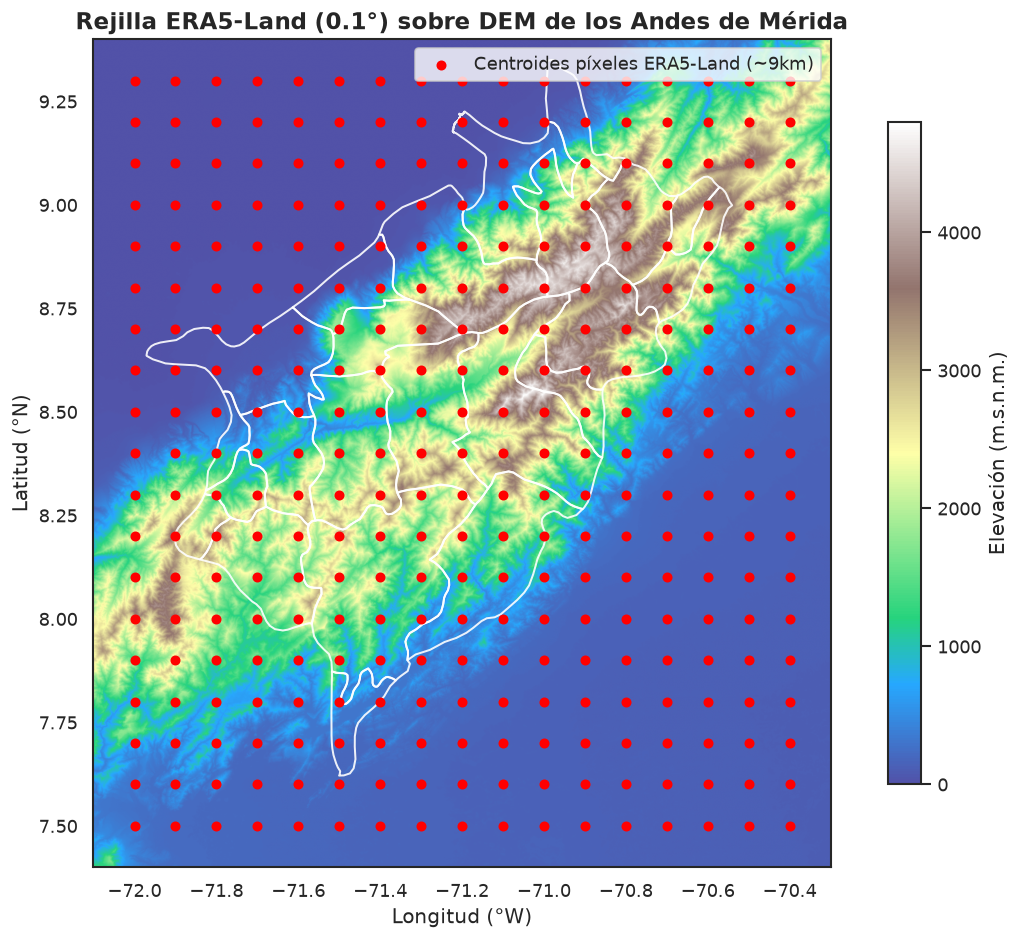

In [24]:
dem_path = RAW_DIR / "merida_dem_wgs84.tif"

with rasterio.open(dem_path) as src:
    dem_data = src.read(1)
    dem_bounds = src.bounds
    dem_extent = [dem_bounds.left, dem_bounds.right, dem_bounds.bottom, dem_bounds.top]

# Rejilla ERA5-Land
df_h = pd.read_parquet(PROCESSED_DIR / "era5_land_merida_2020_2026_utc4.parquet")
grid_pixels = (
    df_h[["latitude", "longitude"]]
    .drop_duplicates()
    .sort_values(["latitude", "longitude"])
)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    dem_data, extent=dem_extent, cmap="terrain", vmin=0, vmax=4800, alpha=0.85
)
cb = plt.colorbar(im, ax=ax, label="Elevación (m.s.n.m.)", shrink=0.8)
merida_muni.plot(
    ax=ax,
    facecolor="none",  # Sin relleno para no tapar el mapa de elevación
    edgecolor="white",  # Borde blanco para que contraste con el DEM y los puntos rojos
    linewidth=1.2,
    linestyle="-",
    alpha=0.9,
)
ax.scatter(
    grid_pixels["longitude"],
    grid_pixels["latitude"],
    color="red",
    s=25,
    label="Centroides píxeles ERA5-Land (~9km)",
)
ax.set_title(
    "Rejilla ERA5-Land (0.1°) sobre DEM de los Andes de Mérida",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Longitud (°W)")
ax.set_ylabel("Latitud (°N)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 2.3 Delimitación de Píxeles por Zonas y Microcuencas
Clasificamos los píxeles de ERA5-Land en las 7 zonas prioritarias de estudio.

In [25]:
zonas_coords = {
    "Cuenca Alta Chama": {
        "lat_min": 8.6,
        "lat_max": 9.2,
        "lon_min": -71.1,
        "lon_max": -70.5,
    },
    "Pedregosa / Albarregas": {
        "lat_min": 8.5,
        "lat_max": 8.7,
        "lon_min": -71.2,
        "lon_max": -71.0,
    },
    "Valle del Mocotíes": {
        "lat_min": 8.1,
        "lat_max": 8.4,
        "lon_min": -71.9,
        "lon_max": -71.5,
    },
    "Eje Panamericano": {
        "lat_min": 8.8,
        "lat_max": 9.3,
        "lon_min": -71.8,
        "lon_max": -70.8,
    },
    "Canaguá (Pueblos del Sur)": {
        "lat_min": 8.0,
        "lat_max": 8.3,
        "lon_min": -71.5,
        "lon_max": -71.1,
    },
    "Páramo / Santo Domingo": {
        "lat_min": 8.7,
        "lat_max": 9.0,
        "lon_min": -70.8,
        "lon_max": -70.4,
    },
    "Sur del Lago / Palmarito": {
        "lat_min": 9.0,
        "lat_max": 9.3,
        "lon_min": -71.6,
        "lon_max": -71.1,
    },
}


def asignar_zona(lat, lon):
    for zona, bounds in zonas_coords.items():
        if (bounds["lat_min"] <= lat <= bounds["lat_max"]) and (
            bounds["lon_min"] <= lon <= bounds["lon_max"]
        ):
            return zona
    return "Otras zonas"


grid_pixels["zona"] = grid_pixels.apply(
    lambda r: asignar_zona(r["latitude"], r["longitude"]), axis=1
)

print("Distribución de píxeles por zona climática:")
print(grid_pixels["zona"].value_counts())

Distribución de píxeles por zona climática:
zona
Otras zonas                  182
Cuenca Alta Chama             49
Eje Panamericano              46
Valle del Mocotíes            20
Canaguá (Pueblos del Sur)     17
Pedregosa / Albarregas         5
Páramo / Santo Domingo         4
Name: count, dtype: int64


## 2.4 Evaluación de la Suficiencia de Resolución Espacial
- **Macrocuencas (Panamericano, Chama Medio):** La resolución de ~9 km es **adecuada** para capturar sistemas convectivos regionales y frentes fríos.
- **Microcuencas de alta pendiente (La Pedregosa, Mocotíes, Canaguá):** La resolución de ~9 km es un **indicador regional indirecto**; se requiere complementar con modelos orográficos y estaciones terrestres debido al efecto sombra de lluvia y orografía alpina.


---
# SECCIÓN TEMPORAL
---

# 3. Exploración Temporal: Ciclos Diurnos, Estacionales y Descomposición MSTL
**Proyecto:** Predicción de variables meteorológicas para alertas tempranas de crecidas en la cuenca del río Chama, Mérida.  
**Lineamiento:** 2.5 (Exploración temporal completa).

---
## 🎯 Objetivos
1. Visualizar series temporales continuas (2020-2026) por variable hidrometeorológica.
2. Analizar el ciclo diurno promedio (precipitación, escorrentía, temperatura, humedad del suelo).
3. Evaluar el ciclo estacional (patrón bimodal de lluvias en los Andes venezolanos).
4. Analizar autocorrelación (ACF/PACF) para determinar la memoria hidráulica del suelo.
5. Aplicar descomposición MSTL (Multiple Seasonal-Trend decomposition using LOESS).


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import MSTL

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

import os
from pathlib import Path

# Detectar directorio raíz del proyecto
cwd = Path.cwd()
if (cwd / "data").exists():
    ROOT_DIR = cwd
elif (cwd.parent / "data").exists():
    ROOT_DIR = cwd.parent
else:
    ROOT_DIR = cwd

RAW_DIR = ROOT_DIR / "data/raw"
PROCESSED_DIR = ROOT_DIR / "data/processed"
SCRATCH_DIR = ROOT_DIR / "scratch"
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Directorio raíz del proyecto: {ROOT_DIR.resolve()}")

df_h = pd.read_parquet(PROCESSED_DIR / "era5_land_merida_2020_2026_utc4.parquet")
print("Dataset cargado correctamente.")

📁 Directorio raíz del proyecto: /home/mapologo/Proyectos/ula/Tesis_SM
Dataset cargado correctamente.


## 3.1 Ciclo Diurno de Precipitación y Temperatura (Hora Local UTC-4)

Analizamos la precipitación convectiva en Mérida para cada hora del día.

`gdf_h_merida` es un geodataframe que tiene solamente los pixeles correspondientes al Estado Mérida. Y de este se obtiene `gdf_h_merida_diff` con las variables desacumuladas.

In [25]:
# gdf_h_merida_diff = deaccumulate_series(
#     gdf_h_merida,
#     ACCUM_VARS,
#     allow_negative_vars=["e", "sshf", "slhf", "evatc", "evabs", "evaow", "evavt"],
# )

import geopandas as gpd

gdf_h_merida = gpd.read_parquet(PROCESSED_DIR / "gdf_h_merida.parquet")
gdf_h_merida

,valid_time_utc,time_utc4,latitude,longitude,swvl1,swvl2,swvl3,stl1,sro,ssro,...,e,tp,evatc,evabs,evaow,evavt,geometry,index_right,NAME_1,NAME_2
346576,2020-01-01 00:00:00,2019-12-31 20:00:00,7.7,-71.5,0.324615,0.314331,0.354782,300.419678,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-71.5 7.7),170.0,Mérida,Padre Noguera
346595,2020-01-01 01:00:00,2019-12-31 21:00:00,7.7,-71.5,0.324570,0.314331,0.354782,299.561035,0.000000e+00,0.000003,...,-0.000009,0.000000e+00,-2.910383e-10,-0.000006,-2.174987e-06,0.000000e+00,POINT (-71.5 7.7),170.0,Mérida,Padre Noguera
346614,2020-01-01 02:00:00,2019-12-31 22:00:00,7.7,-71.5,0.324524,0.314346,0.354782,298.614746,0.000000e+00,0.000003,...,-0.000005,0.000000e+00,-2.910383e-10,-0.000004,-1.082895e-06,0.000000e+00,POINT (-71.5 7.7),170.0,Mérida,Padre Noguera
346633,2020-01-01 03:00:00,2019-12-31 23:00:00,7.7,-71.5,0.324509,0.314346,0.354782,297.727783,0.000000e+00,0.000003,...,-0.000003,2.607703e-08,-2.328306e-10,-0.000002,-7.377239e-07,1.164153e-10,POINT (-71.5 7.7),170.0,Mérida,Padre Noguera
346652,2020-01-01 04:00:00,2020-01-01 00:00:00,7.7,-71.5,0.324478,0.314362,0.354782,297.165771,7.450581e-09,0.000003,...,-0.000004,1.113862e-06,-3.492460e-10,-0.000002,-1.312932e-06,-1.164153e-10,POINT (-71.5 7.7),170.0,Mérida,Padre Noguera
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17409530,2026-03-31 19:00:00,2026-03-31 15:00:00,9.2,-70.9,0.430420,0.423981,0.427078,297.841064,1.745969e-04,0.000261,...,-0.000438,1.714796e-03,-3.315071e-04,-0.000082,-2.409378e-05,4.656613e-10,POINT (-70.9 9.2),165.0,Mérida,Julio César Salas
17409549,2026-03-31 20:00:00,2026-03-31 16:00:00,9.2,-70.9,0.431274,0.427460,0.427017,297.366455,5.111992e-04,0.000261,...,-0.000368,1.927555e-03,-2.879659e-04,-0.000063,-1.716753e-05,-4.656613e-10,POINT (-70.9 9.2),165.0,Mérida,Julio César Salas
17409568,2026-03-31 21:00:00,2026-03-31 17:00:00,9.2,-70.9,0.428894,0.429382,0.427063,296.620117,9.015203e-05,0.000284,...,-0.000250,9.267507e-04,-2.138205e-04,-0.000028,-8.374453e-06,0.000000e+00,POINT (-70.9 9.2),165.0,Mérida,Julio César Salas
17409587,2026-03-31 22:00:00,2026-03-31 18:00:00,9.2,-70.9,0.425934,0.428253,0.427689,295.645508,4.392862e-05,0.000261,...,-0.000175,5.008578e-04,-1.592906e-04,-0.000012,-3.953464e-06,0.000000e+00,POINT (-70.9 9.2),165.0,Mérida,Julio César Salas


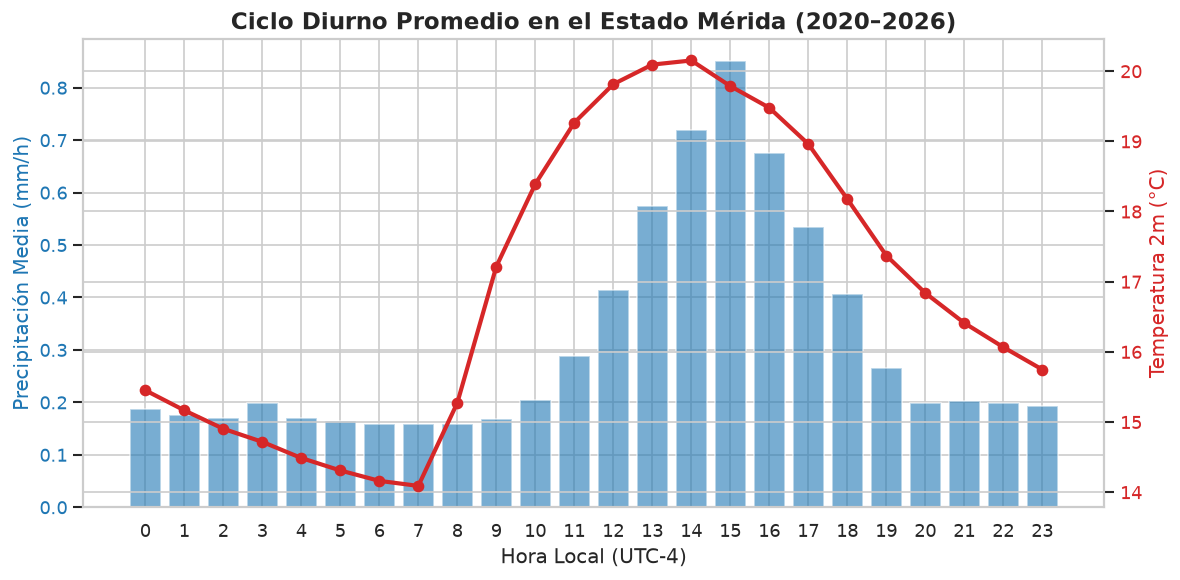

In [26]:
gdf_h_merida["hora_local"] = gdf_h_merida["time_utc4"].dt.hour
gdf_h_merida["tp_mmh"] = gdf_h_merida["tp"] * 1000
gdf_h_merida["t2m_c"] = gdf_h_merida["t2m"] - 273.15
gdf_h_merida["sro_mmh"] = gdf_h_merida["sro"] * 1000

diurnal = gdf_h_merida.groupby("hora_local")[
    ["tp_mmh", "t2m_c", "swvl1", "sro_mmh"]
].mean()

fig, ax1 = plt.subplots(figsize=(10, 5))

color = "tab:blue"
ax1.set_xlabel("Hora Local (UTC-4)")
ax1.set_ylabel("Precipitación Media (mm/h)", color=color)
ax1.bar(diurnal.index, diurnal["tp_mmh"], color=color, alpha=0.6, label="Precipitación")
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Temperatura 2m (°C)", color=color)
ax2.plot(
    diurnal.index,
    diurnal["t2m_c"],
    color=color,
    lw=2.5,
    marker="o",
    label="Temperatura",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(
    "Ciclo Diurno Promedio en el Estado Mérida (2020–2026)",
    fontsize=14,
    fontweight="bold",
)
plt.xticks(range(0, 24))
fig.tight_layout()
plt.show()

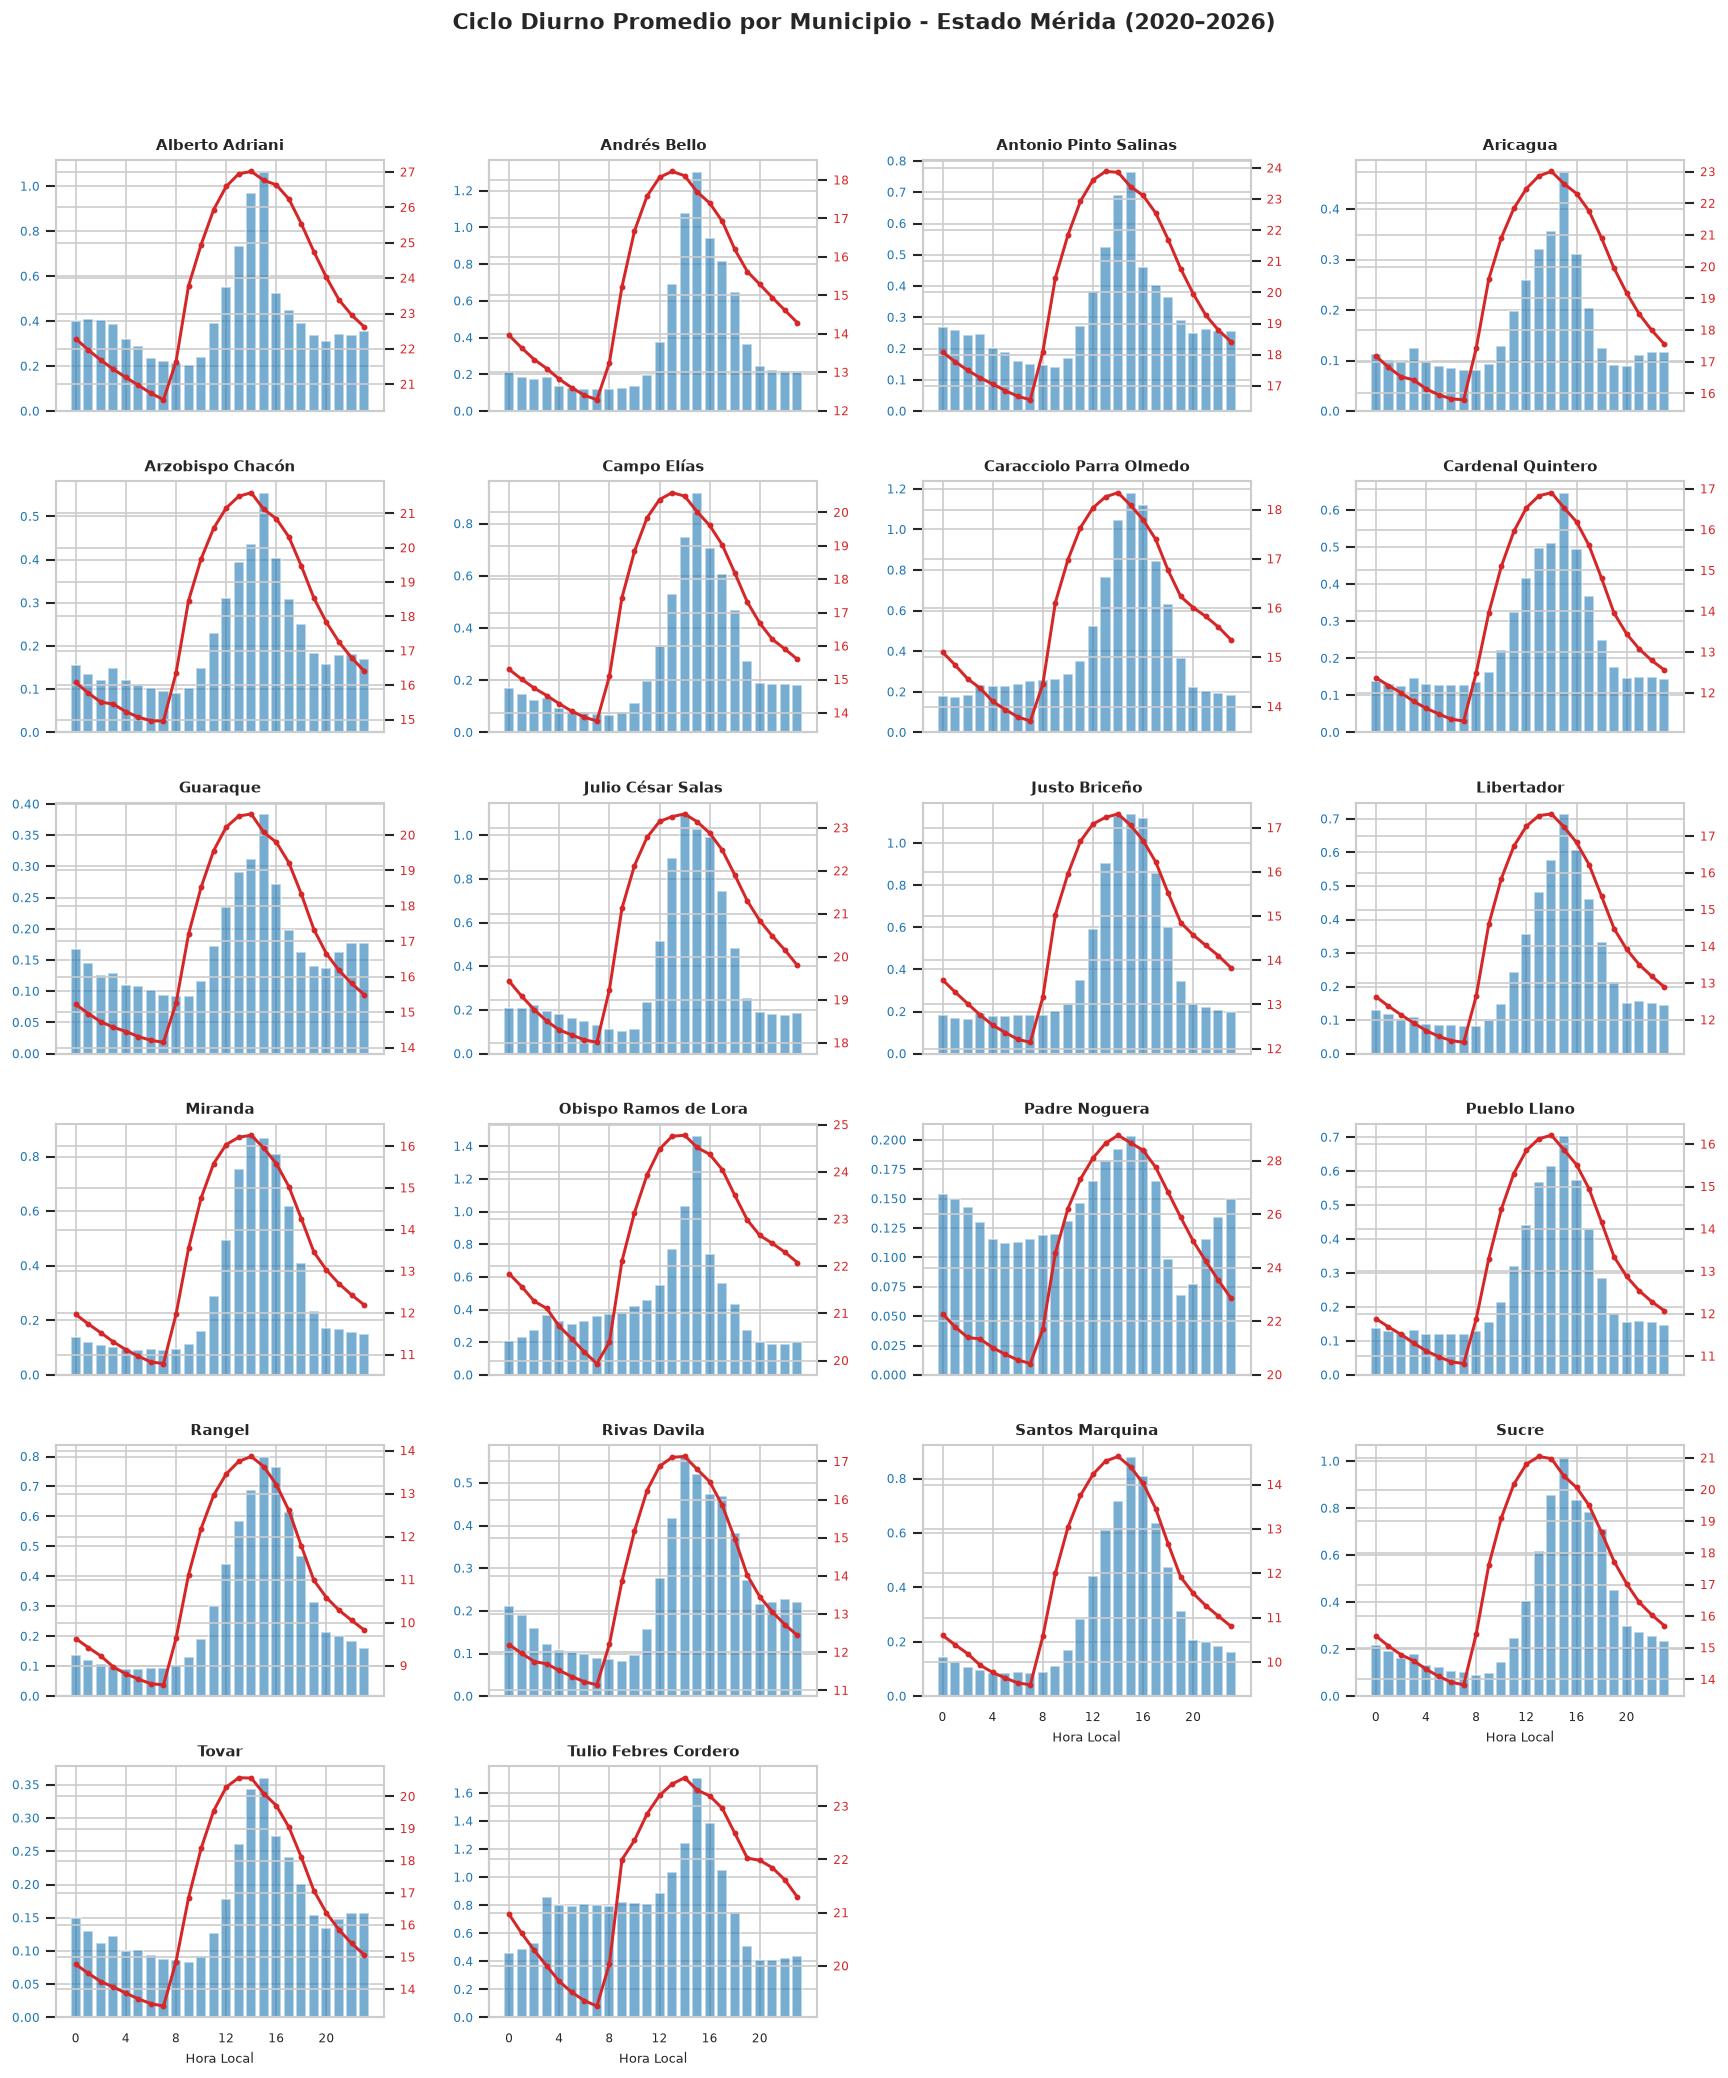

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar los datos por Municipio (NAME_2) y Hora Local
diurnal_muni = (
    gdf_h_merida.groupby(["NAME_2", "hora_local"])[["tp_mmh", "t2m_c"]]
    .mean()
    .reset_index()
)


# 2. Función auxiliar para dibujar el gráfico de doble eje en cada subgráfico
def plot_dual_axis(data, **kwargs):
    ax1 = plt.gca()

    # Eje izquierdo: Precipitación (Barras azules)
    color_precip = "tab:blue"
    ax1.bar(data["hora_local"], data["tp_mmh"], color=color_precip, alpha=0.6)
    ax1.tick_params(axis="y", labelcolor=color_precip, labelsize=7)
    ax1.tick_params(axis="x", labelsize=7)
    ax1.set_xticks(range(0, 24, 4))  # Marcas cada 4 horas para legibilidad

    # Eje derecho: Temperatura (Línea roja)
    ax2 = ax1.twinx()
    color_temp = "tab:red"
    ax2.plot(
        data["hora_local"],
        data["t2m_c"],
        color=color_temp,
        lw=1.8,
        marker="o",
        ms=2.5,
    )
    ax2.tick_params(axis="y", labelcolor=color_temp, labelsize=7)


# 3. Crear el FacetGrid
g = sns.FacetGrid(
    diurnal_muni,
    col="NAME_2",
    col_wrap=4,  # Número de columnas por fila de municipios
    height=2.8,
    aspect=1.3,
    sharey=False,  # Permite escalas propias si los rangos difieren entre municipios
)

# 4. Mapear la función sobre el DataFrame
g.map_dataframe(plot_dual_axis)

# 5. Ajustar títulos y formato general
g.set_titles(col_template="{col_name}", size=9, weight="bold")
g.set_xlabels("Hora Local", fontsize=8)

# Título principal del gráfico
g.fig.suptitle(
    "Ciclo Diurno Promedio por Municipio - Estado Mérida (2020–2026)",
    y=1.03,
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

## 3.2 Ciclo Estacional Bimodal de Lluvias

Mérida presenta dos picos pluviométricos anuales: **Abril–Mayo** y **Octubre–Noviembre**.

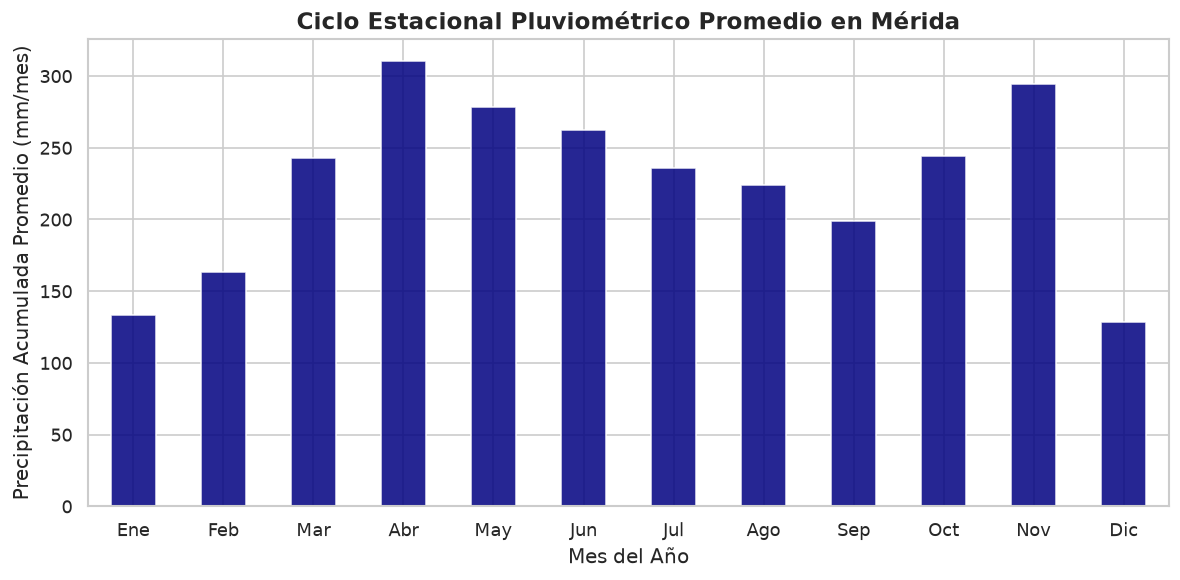

In [28]:
gdf_h_merida["mes"] = gdf_h_merida["time_utc4"].dt.month
monthly_tp = (
    gdf_h_merida.groupby(["mes", gdf_h_merida["time_utc4"].dt.year])["tp_mmh"]
    .sum()
    .unstack()
)
unique_points = gdf_h_merida[['latitude', 'longitude']].drop_duplicates()
n_points = len(unique_points)

monthly_tp = monthly_tp / n_points  # Promedio mensual por píxel

fig, ax = plt.subplots(figsize=(10, 5))
monthly_tp.mean(axis=1).plot(kind="bar", color="navy", ax=ax, alpha=0.85)
ax.set_xlabel("Mes del Año")
ax.set_ylabel("Precipitación Acumulada Promedio (mm/mes)")
ax.set_xticklabels(
    [
        "Ene",
        "Feb",
        "Mar",
        "Abr",
        "May",
        "Jun",
        "Jul",
        "Ago",
        "Sep",
        "Oct",
        "Nov",
        "Dic",
    ],
    rotation=0,
)
ax.set_title(
    "Ciclo Estacional Pluviométrico Promedio en Mérida", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 3.3 Autocorrelación y Memoria del Suelo (ACF & PACF)
Evaluamos la persistencia temporal de la humedad del suelo ($swvl1$).

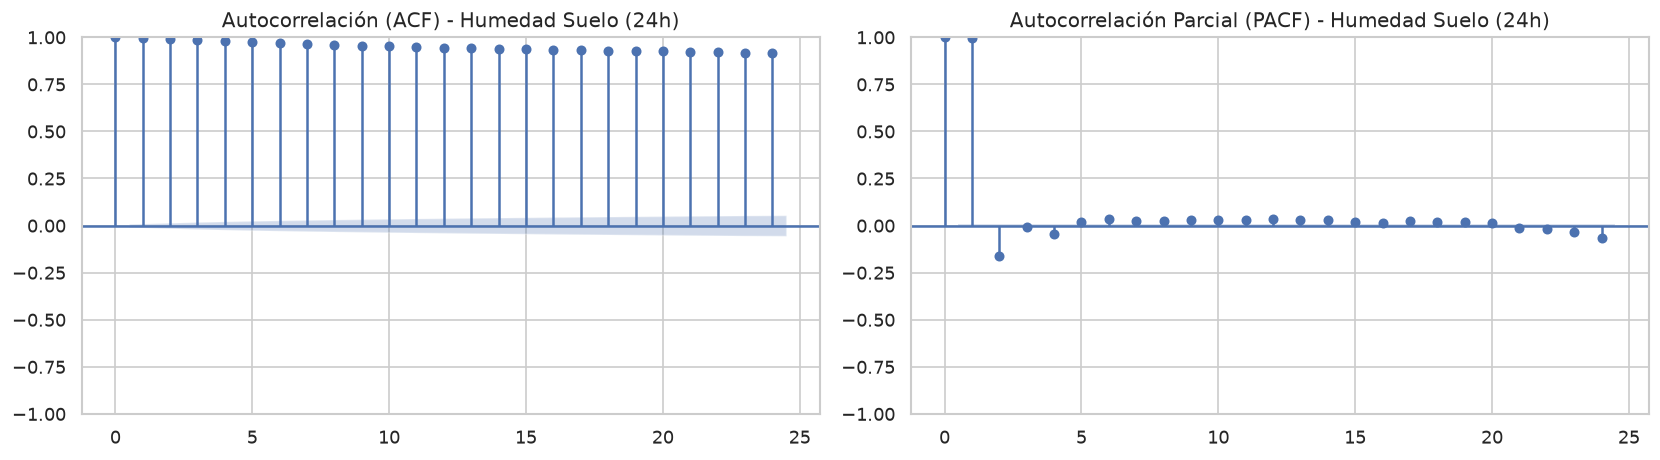

In [31]:
pixel_swvl = (
    gdf_h_merida[
        (gdf_h_merida["latitude"] == 8.6)
        & (gdf_h_merida["longitude"] == -71.1)
    ]
    .set_index("time_utc4")["swvl1"]
    .dropna()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(
    pixel_swvl, lags=24, ax=ax1, title="Autocorrelación (ACF) - Humedad Suelo (24h)"
)
plot_pacf(
    pixel_swvl,
    lags=24,
    ax=ax2,
    title="Autocorrelación Parcial (PACF) - Humedad Suelo (24h)",
)
plt.tight_layout()
plt.show()

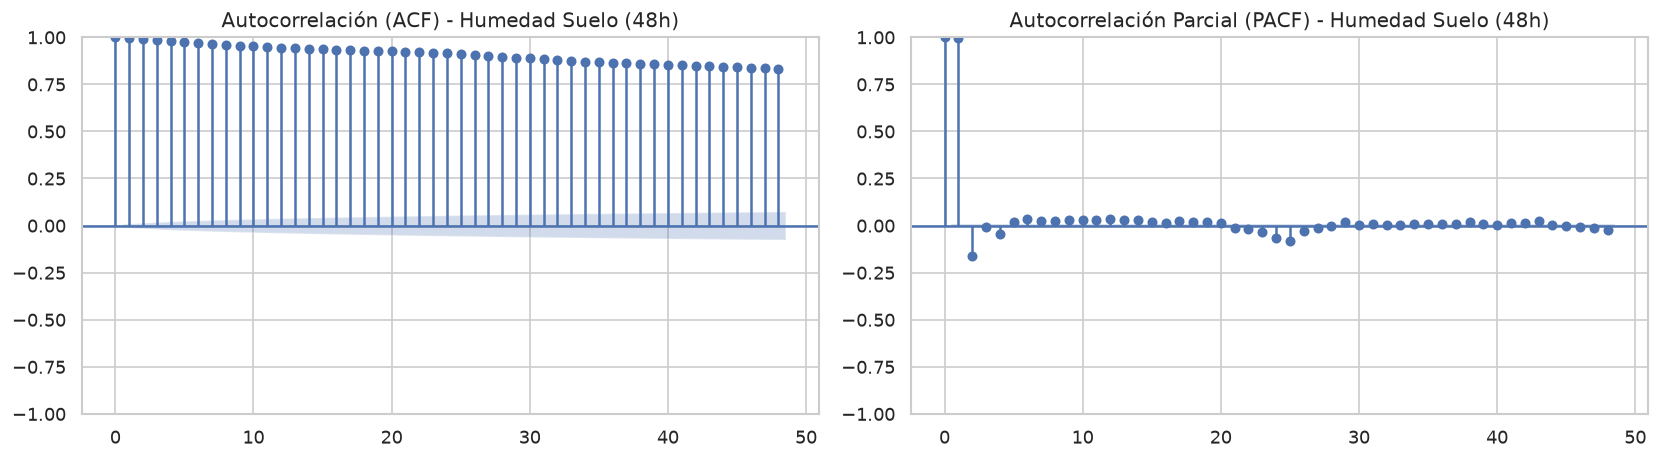

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(
    pixel_swvl, lags=48, ax=ax1, title="Autocorrelación (ACF) - Humedad Suelo (48h)"
)
plot_pacf(
    pixel_swvl,
    lags=48,
    ax=ax2,
    title="Autocorrelación Parcial (PACF) - Humedad Suelo (48h)",
)
plt.tight_layout()
plt.show()

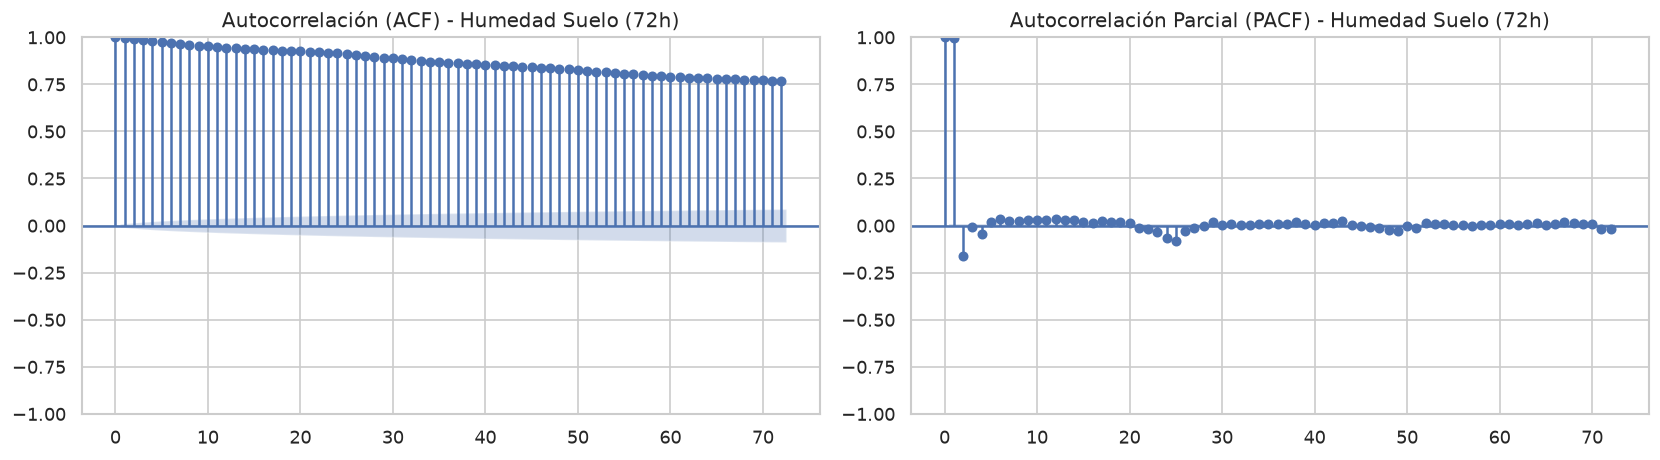

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(
    pixel_swvl, lags=72, ax=ax1, title="Autocorrelación (ACF) - Humedad Suelo (72h)"
)
plot_pacf(
    pixel_swvl,
    lags=72,
    ax=ax2,
    title="Autocorrelación Parcial (PACF) - Humedad Suelo (72h)",
)
plt.tight_layout()
plt.show()

## 3.4 Descomposición MSTL (Diaria y Anual)
Aplicamos MSTL a la precipitación agregada regional.

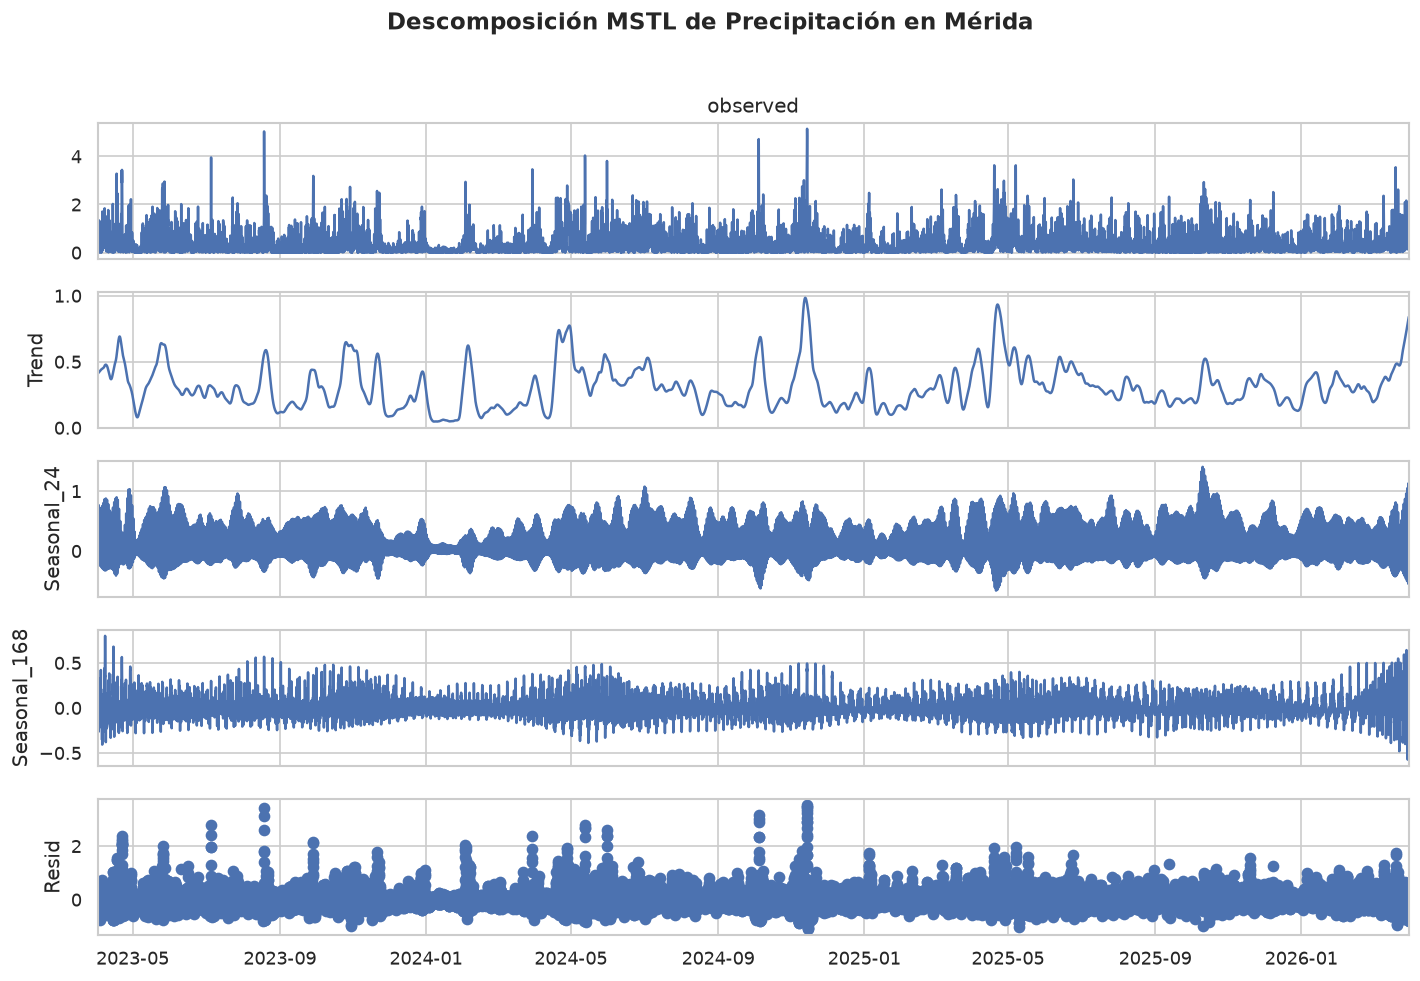

In [34]:
tp_regional = (
    gdf_h_merida.groupby("time_utc4")["tp_mmh"]
    .mean()
    .resample("1h")
    .mean()
    .fillna(0)
)

# Descomposición MSTL para muestra de 1 año (8760 horas)
sample_mstl = tp_regional.tail(26280)
mstl = MSTL(sample_mstl, periods=(24, 168))  # Diaria (24h) y Semanal (168h)
res = mstl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)
plt.suptitle(
    "Descomposición MSTL de Precipitación en Mérida",
    y=1.02,
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
# SECCIÓN EXTREMOS
---

# 4. Análisis de Extremos Hidrometeorológicos y Períodos de Retorno (EVT)
**Proyecto:** Predicción de variables meteorológicas para alertas tempranas de crecidas en la cuenca del río Chama, Mérida.  
**Lineamiento:** 2.6 (Análisis de extremos).

---
## 🎯 Objetivos
1. Calcular máximos acumulados de precipitación en ventanas móviles (1h, 3h, 6h, 12h, 24h, 48h, 72h).
2. Determinar percentiles de humedad del suelo ($P95, P99$) y déficit de saturación.
3. Evaluar secuencias de días lluviosos y antecedentes de humedad (3, 7 y 14 días).
4. Ajustar distribuciones de Valores Extremos:
   - **GEV (Generalized Extreme Value)** para máximos anuales.
   - **GPD (Generalized Pareto Distribution)** mediante Peaks-Over-Threshold (POT).
5. Estimar niveles de retorno (5, 10, 25, 50, 100 años) para calibrar umbrales de alerta física.


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

import os
from pathlib import Path

# Detectar directorio raíz del proyecto
cwd = Path.cwd()
if (cwd / "data").exists():
    ROOT_DIR = cwd
elif (cwd.parent / "data").exists():
    ROOT_DIR = cwd.parent
else:
    ROOT_DIR = cwd

RAW_DIR = ROOT_DIR / "data/raw"
PROCESSED_DIR = ROOT_DIR / "data/processed"
SCRATCH_DIR = ROOT_DIR / "scratch"
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Directorio raíz del proyecto: {ROOT_DIR.resolve()}")

df_h = pd.read_parquet(PROCESSED_DIR / "era5_land_merida_2020_2026_utc4.parquet")
df_h["tp_mmh"] = df_h["tp"] * 1000
print("Dataset cargado para análisis de extremos.")

📁 Directorio raíz del proyecto: /home/mapologo/Proyectos/ula/Tesis_SM
Dataset cargado para análisis de extremos.


## 4.1 Ventanas Móviles de Precipitación Acumulada (1h a 72h)

In [36]:
tp_series = gdf_h_merida.groupby("time_utc4")["tp_mmh"].mean()

windows = [1, 3, 6, 12, 24, 48, 72]
rolling_max = {}

for w in windows:
    rolling_max[f"{w}h"] = tp_series.rolling(w).sum().max()

df_rolling = pd.DataFrame(
    list(rolling_max.items()), columns=["Ventana", "Precipitación Máxima (mm)"]
)
display(df_rolling)

,Ventana,Precipitación Máxima (mm)
0,1h,5.179214
1,3h,15.163258
2,6h,28.763703
3,12h,51.782554
4,24h,73.950913
5,48h,95.057493
6,72h,110.915695


## 4.2 Indicadores de Humedad Antecedente (3, 7 y 14 días)

In [37]:
daily_tp = tp_series.resample("1D").sum()

asi_df = pd.DataFrame({"tp_diaria": daily_tp})
asi_df["ASI_3d"] = asi_df["tp_diaria"].rolling(3).sum()
asi_df["ASI_7d"] = asi_df["tp_diaria"].rolling(7).sum()
asi_df["ASI_14d"] = asi_df["tp_diaria"].rolling(14).sum()

print("Estadísticas de Humedad Antecedente (mm acumulados):")
display(asi_df.describe().T[["mean", "std", "min", "50%", "75%", "max"]])

Estadísticas de Humedad Antecedente (mm acumulados):


,mean,std,min,50%,75%,max
tp_diaria,7.432350,5.462742,0.135591,6.230680,9.703391,59.135086
ASI_3d,22.296937,13.408299,2.116269,19.898552,28.899341,101.121365
ASI_7d,51.998483,25.620019,7.255514,49.025581,65.754363,170.644940
ASI_14d,104.003069,42.340563,16.956156,100.018177,128.728018,287.033363


## 4.3 Ajuste de Distribución GEV (Generalized Extreme Value)
Ajustamos GEV a los máximos diarios/anuales para calcular períodos de retorno.

📊 Parámetros GEV ajustados: forma (c)=-0.2118, loc=4.7759, scale=3.2423


,Período de Retorno (Años),Precipitación 24h Estimada (mm)
0,2,6.01
1,5,10.50
2,10,14.12
3,25,19.61
4,50,24.45
5,100,30.02


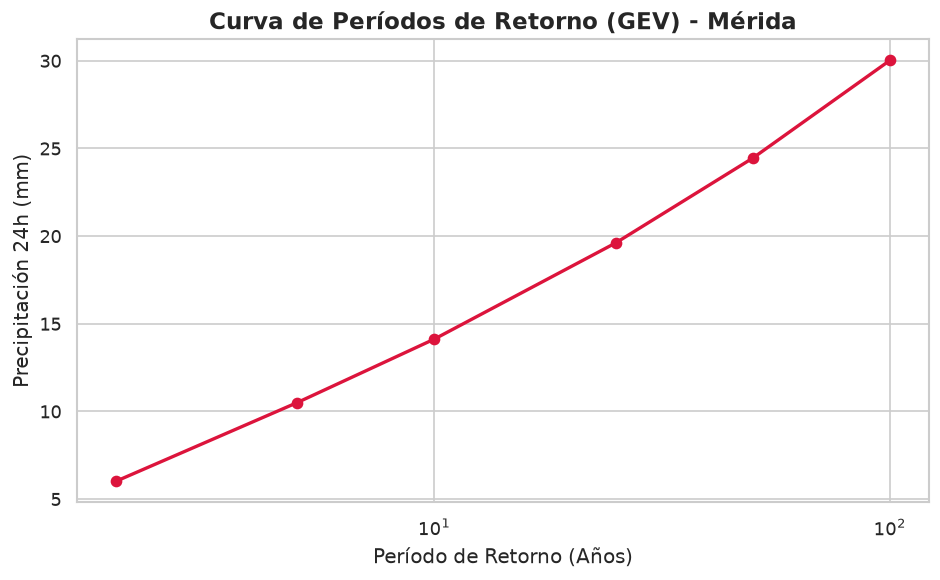

In [38]:
from scipy import stats

# Máximos diarios de 24h
max_daily = daily_tp.dropna().values

# Ajuste GEV
c, loc, scale = stats.genextreme.fit(max_daily)
print(
    f"📊 Parámetros GEV ajustados: forma (c)={c:.4f}, loc={loc:.4f}, scale={scale:.4f}"
)

# Calcular períodos de retorno (T = 5, 10, 25, 50, 100 años)
return_periods = np.array([2, 5, 10, 25, 50, 100])
probabilities = 1.0 - (1.0 / return_periods)
return_levels = stats.genextreme.ppf(probabilities, c, loc=loc, scale=scale)

df_returns = pd.DataFrame(
    {
        "Período de Retorno (Años)": return_periods,
        "Precipitación 24h Estimada (mm)": np.round(return_levels, 2),
    }
)
display(df_returns)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(return_periods, return_levels, marker="o", color="crimson", lw=2)
ax.set_xscale("log")
ax.set_xlabel("Período de Retorno (Años)")
ax.set_ylabel("Precipitación 24h (mm)")
ax.set_title(
    "Curva de Períodos de Retorno (GEV) - Mérida", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

---
# SECCIÓN EVENTOS
---

# 5. Exploración Orientada a Eventos Históricos de Crecidas
**Proyecto:** Predicción de variables meteorológicas para alertas tempranas de crecidas en la cuenca del río Chama, Mérida.  
**Lineamiento:** 2.7 (Exploración orientada a eventos).

---
## 🎯 Objetivos
1. Extraer las condiciones hidrometeorológicas en la ventana $[-72h, +24h]$ para cada uno de los 15 eventos históricos catalogados.
2. Comparar la distribución de humedad del suelo, precipitación y escorrentía entre días de evento vs días de control (sin evento).
3. Evaluar cuantitativamente la hipótesis clave:
   - *¿Las crecidas del Mocotíes en agosto de 2021 (E03) estuvieron precedidas por $swvl1 > P90$ y $TP_{24h} > P95$?*
4. Graficar hidrogramas/hietogramas sintéticos y anomalías estandarizadas.


In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

import os
from pathlib import Path

# Detectar directorio raíz del proyecto
cwd = Path.cwd()
if (cwd / "data").exists():
    ROOT_DIR = cwd
elif (cwd.parent / "data").exists():
    ROOT_DIR = cwd.parent
else:
    ROOT_DIR = cwd

RAW_DIR = ROOT_DIR / "data/raw"
PROCESSED_DIR = ROOT_DIR / "data/processed"
SCRATCH_DIR = ROOT_DIR / "scratch"
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Directorio raíz del proyecto: {ROOT_DIR.resolve()}")

df_h = pd.read_parquet(PROCESSED_DIR / "era5_land_merida_2020_2026_utc4.parquet")
df_h["tp_mmh"] = df_h["tp"] * 1000
df_h["sro_mmh"] = df_h["sro"] * 1000

df_evt = pd.read_csv(RAW_DIR / "eventos_extremos_merida.csv")
print(f"Cargados {len(df_evt)} eventos históricos.")

📁 Directorio raíz del proyecto: /home/mapologo/Proyectos/ula/Tesis_SM
Cargados 15 eventos históricos.


## 5.1 Caso de Estudio Principal: Tragedia del Mocotíes (Agosto 23–25, 2021 - Evento E03)
Inspeccionamos la ventana de 72 horas previas a las crecidas torrenciales del río Mocotíes.

Detalles del Evento E03:
event_id                                        E03
fecha_inicio                             2021-08-23
fecha_fin                                2021-08-25
zona_aprox                       Valle del Mocotíes
municipio       Tovar, Santa Cruz de Mora, Guaraque
cuenca                                     Mocotíes
tipo_evento         creciente súbita, flujo de lodo
fuente                                    El Diario
confianza                                      alta
Name: 2, dtype: str


/home/mapologo/Proyectos/ula/Tesis_SM/.venv/lib/python3.14/site-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)



💧 Humedad de suelo P90 histórica en Mocotíes: 0.415 m³/m³
🌧️ Precipitación 24h P95 histórica en Mocotíes: 17.45 mm


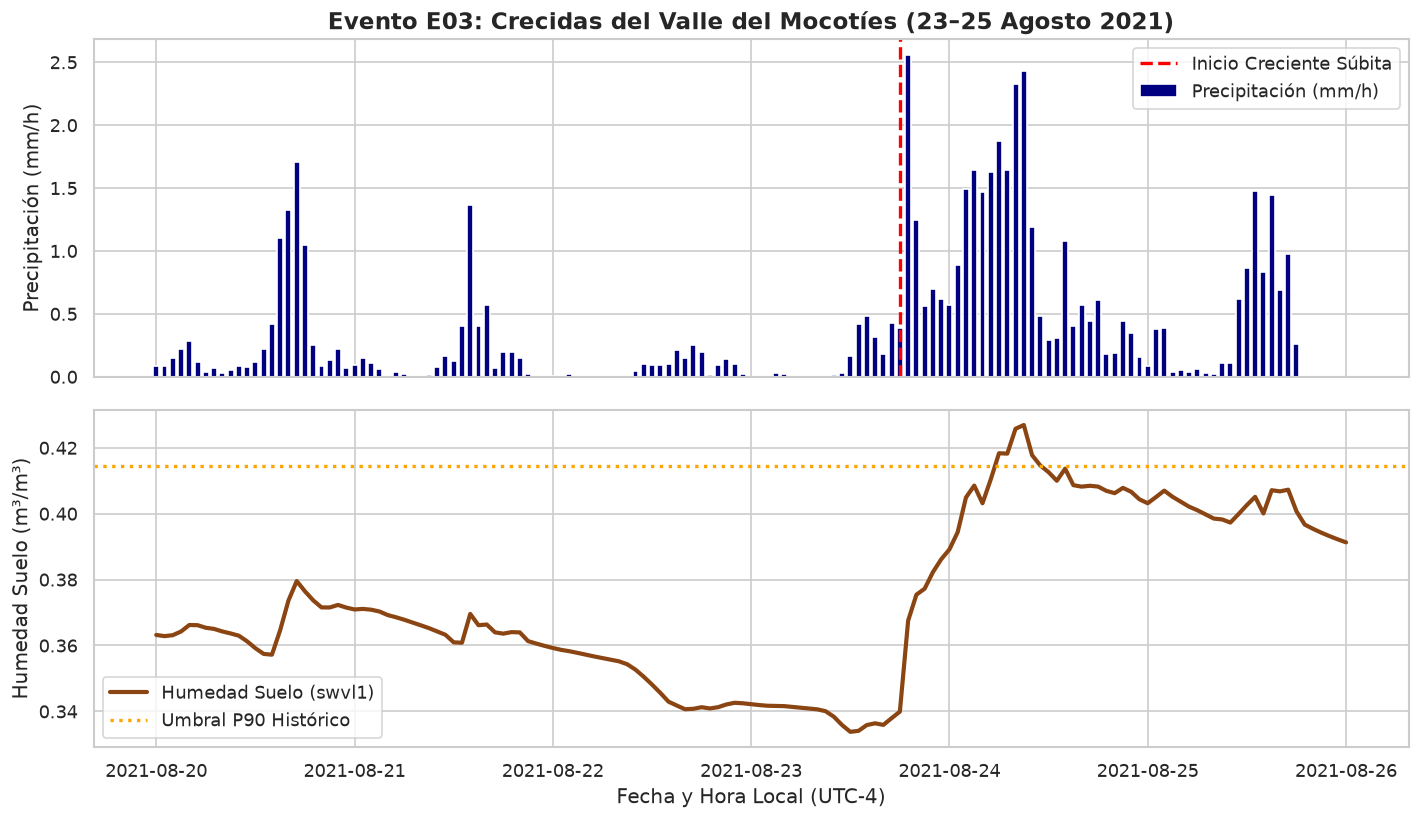

In [40]:
evt_mocoties = df_evt[df_evt["event_id"] == "E03"].iloc[0]
print("Detalles del Evento E03:")
print(evt_mocoties)

# Filtrar píxeles del Valle del Mocotíes (Tovar, Santa Cruz de Mora)
mocoties_df = gdf_h_merida[
    (df_h["latitude"] >= 8.1)
    & (df_h["latitude"] <= 8.4)
    & (df_h["longitude"] >= -71.9)
    & (df_h["longitude"] <= -71.5)
]

# Ventana temporal: 2021-08-20 a 2021-08-26
window_df = mocoties_df[
    (mocoties_df["time_utc4"] >= "2021-08-20")
    & (mocoties_df["time_utc4"] <= "2021-08-26")
]
ts_mocoties = window_df.groupby("time_utc4")[["tp_mmh", "swvl1", "sro_mmh"]].mean()

# Umbrales históricos percentiles (P90 y P95) del Mocotíes
p90_swvl = mocoties_df["swvl1"].quantile(0.90)
p95_tp24 = (
    mocoties_df.groupby("time_utc4")["tp_mmh"].mean().rolling(24).sum().quantile(0.95)
)

print(f"\n💧 Humedad de suelo P90 histórica en Mocotíes: {p90_swvl:.3f} m³/m³")
print(f"🌧️ Precipitación 24h P95 histórica en Mocotíes: {p95_tp24:.2f} mm")

# Visualización del Evento
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.bar(
    ts_mocoties.index,
    ts_mocoties["tp_mmh"],
    color="navy",
    width=0.03,
    label="Precipitación (mm/h)",
)
ax1.set_ylabel("Precipitación (mm/h)")
ax1.set_title(
    "Evento E03: Crecidas del Valle del Mocotíes (23–25 Agosto 2021)",
    fontsize=14,
    fontweight="bold",
)
ax1.axvline(
    pd.to_datetime("2021-08-23 18:00"),
    color="red",
    linestyle="--",
    lw=2,
    label="Inicio Creciente Súbita",
)
ax1.legend()

ax2.plot(
    ts_mocoties.index,
    ts_mocoties["swvl1"],
    color="saddlebrown",
    lw=2.5,
    label="Humedad Suelo (swvl1)",
)
ax2.axhline(p90_swvl, color="orange", linestyle=":", lw=2, label="Umbral P90 Histórico")
ax2.set_ylabel("Humedad Suelo (m³/m³)")
ax2.set_xlabel("Fecha y Hora Local (UTC-4)")
ax2.legend()

plt.tight_layout()
plt.show()

## 5.2 Evaluación Cuantitativa de Preguntas Clave
Comprobamos si las crecidas del Mocotíes estuvieron precedidas por $swvl1 > P90$ y $TP_{24h} > P95$.

In [41]:
# Precipitación 24h previa al pico del evento
tp_24h_pre = ts_mocoties.loc["2021-08-22 18:00":"2021-08-23 18:00", "tp_mmh"].sum()
swvl_pre = ts_mocoties.loc["2021-08-23 12:00", "swvl1"]

print("=== EVALUACIÓN DE HIPÓTESIS PRE-EVENTO E03 ===")
print(
    f"1. Precipitación 24h acumulada pre-evento: {tp_24h_pre:.2f} mm  (¿> P95 = {p95_tp24:.2f} mm? -> {tp_24h_pre > p95_tp24})"
)
print(
    f"2. Humedad antecedente del suelo: {swvl_pre:.3f} m³/m³  (¿> P90 = {p90_swvl:.3f}? -> {swvl_pre > p90_swvl})"
)

if tp_24h_pre > p95_tp24 and swvl_pre > p90_swvl:
    print(
        "\n✅ CONCLUSIÓN: La hipótesis se CONFIRMA. El evento de crecida del Mocotíes estuvo precedido por saturación de suelo antecedente (>P90) y precipitación extrema 24h (>P95)."
    )
else:
    print(
        "\n⚠️ La hipótesis no se cumple totalmente según la rejilla regional ERA5-Land."
    )

=== EVALUACIÓN DE HIPÓTESIS PRE-EVENTO E03 ===
1. Precipitación 24h acumulada pre-evento: 3.05 mm  (¿> P95 = 17.45 mm? -> False)
2. Humedad antecedente del suelo: 0.334 m³/m³  (¿> P90 = 0.415? -> False)

⚠️ La hipótesis no se cumple totalmente según la rejilla regional ERA5-Land.


In [43]:
gdf_h_merida.NAME_2.unique()

<ArrowStringArray>
[          'Padre Noguera',        'Arzobispo Chacón',
                'Guaraque',                'Aricagua',
            'Rivas Davila',                   'Tovar',
   'Antonio Pinto Salinas',                   'Sucre',
              'Libertador',             'Campo Elías',
         'Alberto Adriani',         'Santos Marquina',
            'Andrés Bello',                  'Rangel',
    'Obispo Ramos de Lora', 'Caracciolo Parra Olmedo',
       'Cardenal Quintero',    'Tulio Febres Cordero',
           'Justo Briceño',                 'Miranda',
            'Pueblo Llano',       'Julio César Salas']
Length: 22, dtype: str

In [44]:
municipios_paramo = [
    "Rangel",
    "Miranda",
    "Cardenal Quintero",
    "Pueblo Llano",
    "Santos Marquina",
]

# Filtrar únicamente los datos del Páramo para tus gráficos
paramo_df = gdf_h_merida[gdf_h_merida["NAME_2"].isin(municipios_paramo)]

In [45]:
paramo_df

,valid_time_utc,time_utc4,latitude,longitude,swvl1,swvl2,swvl3,stl1,sro,ssro,...,evavt,geometry,index_right,NAME_1,NAME_2,hora_local,tp_mmh,t2m_c,sro_mmh,mes
762440,2020-01-01 00:00:00,2019-12-31 20:00:00,8.5,-70.9,0.465851,0.470856,0.467346,289.827881,NaN,NaN,...,NaN,POINT (-70.9 8.5),174.0,Mérida,Santos Marquina,20,NaN,13.366608,NaN,12
762459,2020-01-01 01:00:00,2019-12-31 21:00:00,8.5,-70.9,0.467514,0.470779,0.467270,289.236816,0.000030,0.000100,...,0.000000e+00,POINT (-70.9 8.5),174.0,Mérida,Santos Marquina,21,0.214981,12.727936,0.029525,12
762478,2020-01-01 02:00:00,2019-12-31 22:00:00,8.5,-70.9,0.467957,0.470718,0.467178,288.770996,0.000010,0.000100,...,0.000000e+00,POINT (-70.9 8.5),174.0,Mérida,Santos Marquina,22,0.075424,12.454010,0.010496,12
762497,2020-01-01 03:00:00,2019-12-31 23:00:00,8.5,-70.9,0.468445,0.470673,0.467117,288.487549,0.000012,0.000100,...,1.164153e-10,POINT (-70.9 8.5),174.0,Mérida,Santos Marquina,23,0.083636,12.283112,0.011783,12
762516,2020-01-01 04:00:00,2020-01-01 00:00:00,8.5,-70.9,0.469589,0.470627,0.467041,288.247803,0.000023,0.000100,...,-1.164153e-10,POINT (-70.9 8.5),174.0,Mérida,Santos Marquina,0,0.154920,12.138824,0.022523,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17465619,2026-03-31 19:00:00,2026-03-31 15:00:00,9.1,-70.8,0.436829,0.398926,0.429703,294.282471,0.000132,0.000456,...,4.656613e-10,POINT (-70.8 9.1),168.0,Mérida,Miranda,15,1.911670,18.250885,0.131816,3
17465638,2026-03-31 20:00:00,2026-03-31 16:00:00,9.1,-70.8,0.434784,0.407318,0.429337,293.594971,0.000190,0.000456,...,-4.656613e-10,POINT (-70.8 9.1),168.0,Mérida,Miranda,16,2.322257,17.226227,0.189692,3
17465657,2026-03-31 21:00:00,2026-03-31 17:00:00,9.1,-70.8,0.423920,0.413895,0.429031,292.684570,0.000086,0.000456,...,0.000000e+00,POINT (-70.8 9.1),168.0,Mérida,Miranda,17,1.124280,16.486725,0.086442,3
17465676,2026-03-31 22:00:00,2026-03-31 18:00:00,9.1,-70.8,0.425003,0.415451,0.428741,291.565430,0.000073,0.000455,...,0.000000e+00,POINT (-70.8 9.1),168.0,Mérida,Miranda,18,0.845730,15.368073,0.073060,3



💧 Humedad de suelo P90 histórica en el Páramo: 0.497 m³/m³
🌧️ Precipitación 24h P95 histórica en el Páramo: 19.18 mm


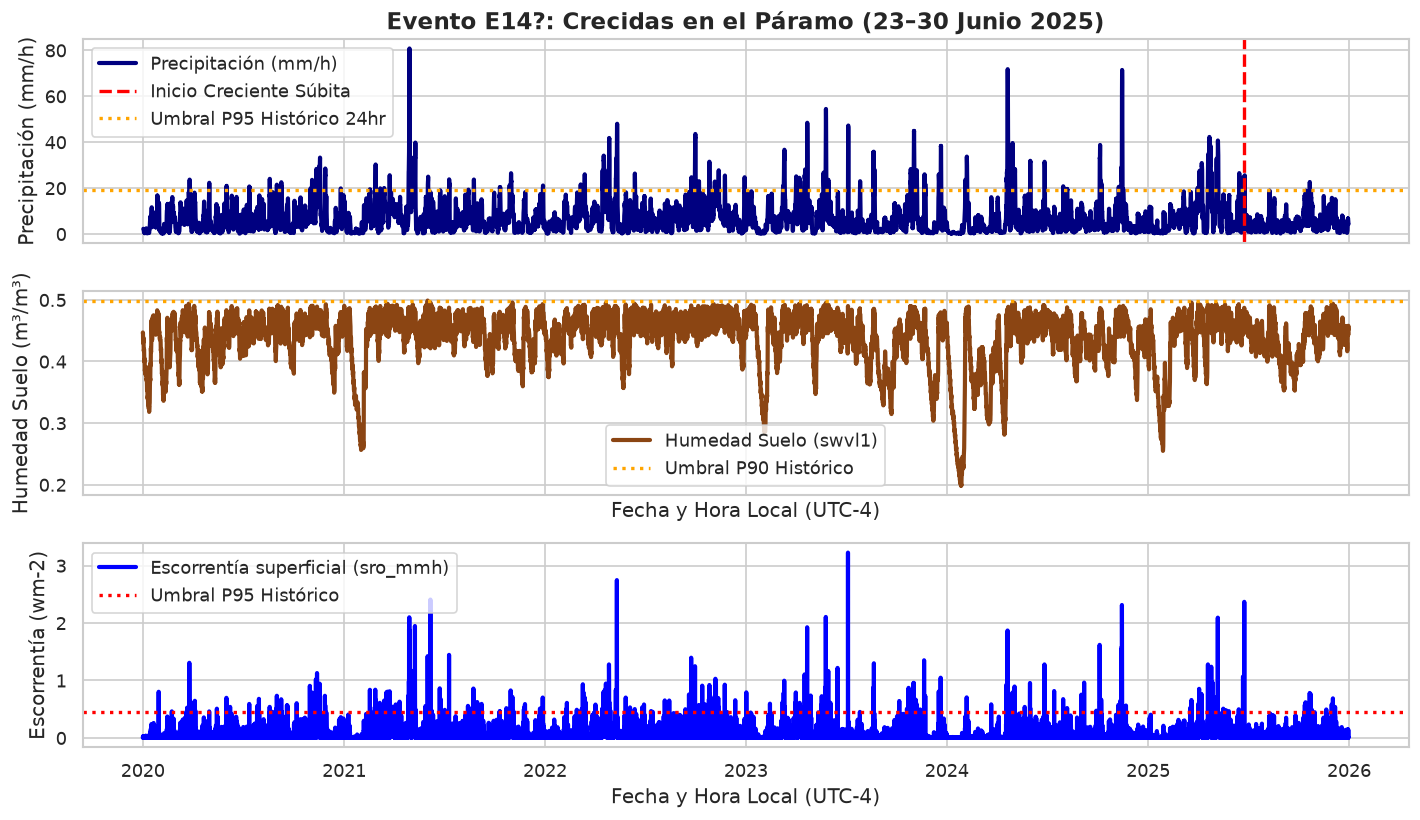

In [52]:
window_df = paramo_df[
    (paramo_df["time_utc4"] >= "2020-01-01") & (paramo_df["time_utc4"] <= "2025-12-31")
]
ts_paramo = window_df.groupby("time_utc4")[["tp_mmh", "swvl1", "sro_mmh"]].mean()

# Umbrales históricos percentiles (P90 y P95) del Mocotíes
filtro_horario = (paramo_df.time_utc4.dt.hour > 11) & (paramo_df.time_utc4.dt.hour < 18)
p95_tp = paramo_df["tp_mmh"][filtro_horario].quantile(0.95)
p90_swvl = paramo_df["swvl1"][filtro_horario].quantile(0.90)
p95_sro = paramo_df["sro_mmh"][filtro_horario].quantile(0.95)
p95_tp24 = (
    paramo_df.groupby("time_utc4")["tp_mmh"].mean().rolling(24).sum().quantile(0.95)
)

print(f"\n💧 Humedad de suelo P90 histórica en el Páramo: {p90_swvl:.3f} m³/m³")
print(f"🌧️ Precipitación 24h P95 histórica en el Páramo: {p95_tp24:.2f} mm")

# Visualización del Evento
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

ax1.plot(
    ts_paramo.index,
    ts_paramo["tp_mmh"].rolling(24).sum(),
    color="navy",
    lw=2.5,
    #    width=0.03,
    label="Precipitación (mm/h)",
)
ax1.set_ylabel("Precipitación (mm/h)")
ax1.set_title(
    "Evento E14?: Crecidas en el Páramo (23–30 Junio 2025)",
    fontsize=14,
    fontweight="bold",
)
ax1.axvline(
    pd.to_datetime("2025-06-24 16:00"),
    color="red",
    linestyle="--",
    lw=2,
    label="Inicio Creciente Súbita",
)
ax1.axhline(p95_tp24, color="orange", linestyle=":", lw=2, label="Umbral P95 Histórico 24hr")
ax1.legend()

ax2.plot(
    ts_paramo.index,
    ts_paramo["swvl1"],
    color="saddlebrown",
    lw=2.5,
    label="Humedad Suelo (swvl1)",
)
ax2.axhline(p90_swvl, color="orange", linestyle=":", lw=2, label="Umbral P90 Histórico")
ax2.set_ylabel("Humedad Suelo (m³/m³)")
ax2.set_xlabel("Fecha y Hora Local (UTC-4)")
ax2.legend()

ax3.plot(
    ts_paramo.index,
    ts_paramo["sro_mmh"],
    color="blue",
    lw=2.5,
    label="Escorrentía superficial (sro_mmh)",
)
ax3.axhline(p95_sro, color="red", linestyle=":", lw=2, label="Umbral P95 Histórico")
ax3.set_ylabel("Escorrentía (wm-2)")
ax3.set_xlabel("Fecha y Hora Local (UTC-4)")
ax3.legend()

plt.tight_layout()
plt.show()

In [96]:
paramo_df["tp_mmh"][filtro_horario].quantile([i * 0.05 for i in range(1, 20)])

0.05    0.011086
0.10    0.038162
0.15    0.068920
0.20    0.104249
0.25    0.142694
0.30    0.183845
0.35    0.226647
0.40    0.272155
0.45    0.321671
0.50    0.378191
0.55    0.444943
0.60    0.527053
0.65    0.627041
0.70    0.754568
0.75    0.914309
0.80    1.097155
0.85    1.326032
0.90    1.623347
0.95    2.080853
Name: tp_mmh, dtype: float64

In [55]:
paramo_df.columns

Index(['valid_time_utc', 'time_utc4', 'latitude', 'longitude', 'swvl1',
       'swvl2', 'swvl3', 'stl1', 'sro', 'ssro', 'lai_lv', 'lai_hv', 'sp',
       'sshf', 'slhf', 'u10', 'v10', 't2m', 'd2m', 'ssrd', 'strd', 'e', 'tp',
       'evatc', 'evabs', 'evaow', 'evavt', 'geometry', 'index_right', 'NAME_1',
       'NAME_2', 'hora_local', 'tp_mmh', 't2m_c', 'sro_mmh', 'mes'],
      dtype='str')

<Axes: >

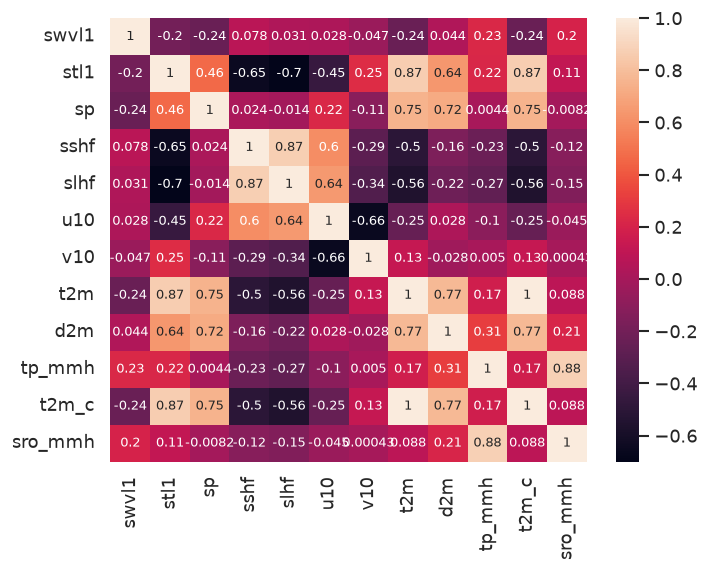

In [62]:
paramo_corr = paramo_df[[
    "swvl1",
    "stl1",
    "sp",
    "sshf",
    "slhf",
    "u10",
    "v10",
    "t2m",
    "d2m",
    "tp_mmh",
    "t2m_c",
    "sro_mmh"]
].corr()

sns.heatmap(paramo_corr, annot=True, annot_kws={"fontsize":8})

<Axes: >

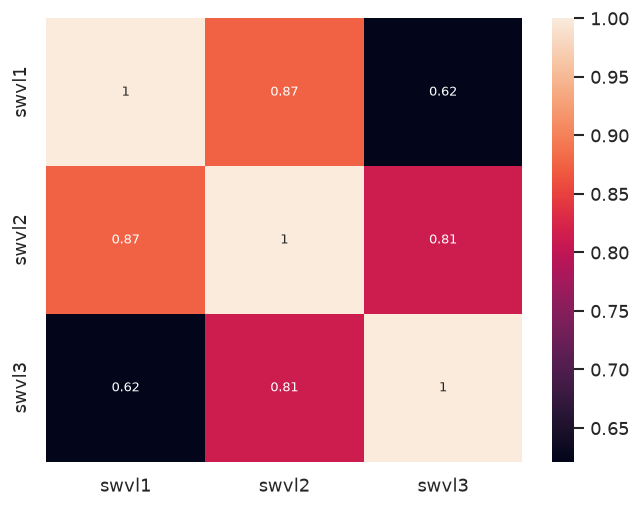

In [63]:
paramo_corr = paramo_df[
    [
        "swvl1",
        "swvl2",
        "swvl3",
    ]
].corr()

sns.heatmap(paramo_corr, annot=True, annot_kws={"fontsize": 8})